# **Section 1: Import**

## **Import & Define**

In [ ]:
# INSTALL PACKAGES
import subprocess, sys

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade', 'pip', 'setuptools'])

packages = [
    'yfinance', 'PyPortfolioOpt', 'scikit-learn', 'statsmodels',
    'scipy', 'matplotlib', 'seaborn', 'pandas', 'numpy', 'openpyxl'
]

for pkg in packages:
    try:
        result = subprocess.run(
            [sys.executable, '-m', 'pip', 'install', pkg],
            capture_output=True, text=True, check=True
        )
    except subprocess.CalledProcessError as e:
        raise
    except Exception as e:
        raise

In [ ]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os
import io

from sklearn.covariance import ShrunkCovariance, empirical_covariance, log_likelihood
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import QuantileTransformer
from sklearn.linear_model import LinearRegression

from scipy import linalg
from scipy.stats import linregress, gaussian_kde
import scipy.stats as stats

import statsmodels.api as sm
from collections import OrderedDict

from pypfopt import (
    black_litterman, risk_models,
    BlackLittermanModel, plotting,
    EfficientFrontier, objective_functions
)
from pypfopt.risk_models import CovarianceShrinkage

import random
import datetime

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [ ]:
# DEFINE TICKERS
tickers_dict = {
    "Communication Services": ["VZ"],
    "Financials": ["JPM", "BAC"],
    "Energy": ["XOM", "CVX"],
    "Healthcare": ["UNH", "JNJ", "ABBV"],
    "Industrials": ["CAT", "HON", "RTX"],
    "Consumer Staples": ["PG", "WMT"],
    "Utilities": ["NEE"]
}

equity_tickers = [t for sector in tickers_dict.values() for t in sector]
print(f"Total equity tickers: {len(equity_tickers)}")
print("Tickers:", equity_tickers)

sector_bounds = {
    "Communication Services": 0.01 ,
    "Financials": 0.15,
    "Energy": 0.13,
    "Healthcare": 0.28,
    "Industrials": 0.26,
    "Consumer Staples": 0.12 ,
    "Utilities": 0.05,
}

INITIAL_CAPITAL     = 50000000
EQUITY_WEIGHT       = 0.99
CASH_WEIGHT         = 0.01
REBALANCE_THRESHOLD = 0.05

print(f"\nInitial Capital  : ${INITIAL_CAPITAL:,.0f}")
print(f"Equity allocation: {EQUITY_WEIGHT*100:.0f}%")
print(f"Cash allocation  : {CASH_WEIGHT*100:.0f}%")
print(f"Rebalance trigger: ±{REBALANCE_THRESHOLD*100:.0f}% drift")

Total equity tickers: 14
Tickers: ['VZ', 'JPM', 'BAC', 'XOM', 'CVX', 'UNH', 'JNJ', 'ABBV', 'CAT', 'HON', 'RTX', 'PG', 'WMT', 'NEE']

Initial Capital  : $50,000,000
Equity allocation: 99%
Cash allocation  : 1%
Rebalance trigger: ±5% drift


In [ ]:
# DEFINE UTILITIES
class DataProcessor:
    """Converts price series to returns."""

    @staticmethod
    def return_from_prices(prices, log_returns=False):
        if log_returns:
            return np.log(1 + prices.pct_change()).dropna(how='all')
        return prices.pct_change().dropna(how='all')


class VcvEstimation:
    """Ledoit-Wolf / Shrinkage covariance helpers (mirrors utils.py)."""

    @staticmethod
    def get_number_of_features(dict_data):
        return sum(len(v) for v in dict_data.values())

    @staticmethod
    def color_matrix(num_features):
        return np.random.randn(num_features, num_features)

    @staticmethod
    def shrinkage_factor():
        return np.logspace(-2, 0, 32)

    @staticmethod
    def negative_log_likelihood(shrinkage_factor, train, test):
        return [-ShrunkCovariance(shrinkage=s).fit(train).score(test) for s in shrinkage_factor]

    @staticmethod
    def real_covariance(color_matrix):
        return np.dot(color_matrix.T, color_matrix)

    @staticmethod
    def log_real_likelihood(empirical_cov, real_cov):
        return -log_likelihood(empirical_cov, linalg.inv(real_cov))

    @staticmethod
    def get_optimal_shrinkage_coefficient(tuned_parameters, train):
        cv = GridSearchCV(ShrunkCovariance(), tuned_parameters)
        cv.fit(train)
        return cv, cv.best_estimator_.shrinkage


class BlackLittermanHelper:
    """Black-Litterman helper (mirrors utils.py BlackLitterman class)."""

    def get_target_prices(self):
        """Returns a pre-loaded target price Series (integrated from target_price.xlsx)."""
        data = {
    'JPM': 281.42,
    'BAC': 47.04,
    'XOM': 115.29,
    'CVX': 154.06,
    'CAT': 392.23,
    'UNH': 317.31,
    'JNJ': 163.13,
    'ABBV': 195.60,
    'HON': 242.76,
    'RTX': 146.17,
    'PG': 179.74,
    'WMT': 104.45,
    'NEE': 75.66,
    'VZ': 49.37
        }
        return pd.Series(data)

    @staticmethod
    def get_confidences(view_dict):
        """Assigns confidence levels based on magnitude of analyst view (mirrors utils.py logic)."""
        def calc_conf(v):
            if abs(v) > 0.3:
                return random.choice([0.7, 0.8, 0.9])
            elif abs(v) > 0.1:
                return random.choice([0.4, 0.5, 0.6])
            else:
                return random.choice([0.1, 0.2, 0.3])
        return [calc_conf(r) for r in view_dict.values()]


class FamaFrenchHelper:
    """Loads and parses the Fama-French CSV (mirrors utils.py FamaFrench class)."""

    @staticmethod
    def get_factors(filepath):
        """
        Load FF daily factors from a local CSV file.
        USAGE: Pass the full path to F-F_Research_Data_Factors_daily.CSV
        """
        df = pd.read_csv(filepath)
        df = df.rename(columns={'Unnamed: 0': 'Date'})
        if len(str(df['Date'].iloc[0])) == 6:
            df['Date'] = df['Date'].apply(lambda x: pd.to_datetime(str(x), format='%Y%m'))
        else:
            df['Date'] = df['Date'].apply(lambda x: pd.to_datetime(str(x), format='%Y%m%d'))
        df = df.set_index('Date')
        df = df / 100
        return df

## **Data Download**

In [ ]:
# PRICE (for weighting)
ALLOC_START = '2020-04-30'
ALLOC_END   = '2025-04-30'

raw = yf.download(equity_tickers, start=ALLOC_START, end=ALLOC_END, auto_adjust=True, progress=False)

if isinstance(raw.columns, pd.MultiIndex):
    prices_alloc = raw['Close']
else:
    prices_alloc = raw[['Close']]

prices_alloc.ffill(inplace=True)
prices_alloc.bfill(inplace=True)

print(f"Date range in data: {prices_alloc.index[0].date()} → {prices_alloc.index[-1].date()}")
prices_alloc.tail(3)

Date range in data: 2020-04-30 → 2025-04-29


Ticker,ABBV,BAC,CAT,CVX,HON,JNJ,JPM,NEE,PG,RTX,UNH,VZ,WMT,XOM
Date,,,,,,,,,,,,,,
2025-04-25,180.189743,38.816921,303.168915,131.550812,182.765366,149.529892,238.903809,64.181244,156.517517,122.630478,407.158844,39.264122,94.074104,104.255890
2025-04-28,186.271606,38.904938,303.772430,132.849930,184.141891,150.274750,238.580093,64.278358,157.324295,122.219162,408.481537,39.713821,94.202728,104.313507
2025-04-29,187.404694,39.110321,304.108765,132.091339,194.080383,150.816437,239.953369,65.307747,157.722839,123.129921,398.006897,40.238464,95.013962,104.054245


In [ ]:
# MARKET CAPITAL (for weighting)
caps_dict = {}
for ticker in equity_tickers:
    try:
        info = yf.Ticker(ticker).info
        shares = info.get('sharesOutstanding', None)
        last_price = prices_alloc[ticker].dropna().iloc[-1]
        if shares:
            caps_dict[ticker] = last_price * shares
        else:
            caps_dict[ticker] = info.get('marketCap', np.nan)
    except Exception as e:
        print(f"  ⚠️  {ticker}: {e}")
        caps_dict[ticker] = np.nan

caps_series = pd.Series(caps_dict).dropna()
print("\nMarket Caps (USD):")
print(caps_series.apply(lambda x: f"${x/1e9:.1f}B"))


Market Caps (USD):
VZ      $168.0B
JPM     $643.0B
BAC     $277.5B
XOM     $431.3B
CVX     $263.1B
UNH     $361.4B
JNJ     $363.0B
ABBV    $331.1B
CAT     $140.1B
HON     $123.0B
RTX     $165.8B
PG      $367.3B
WMT     $756.1B
NEE     $136.2B
dtype: object


In [54]:
# RISK-FREE RATE (for weighting)
rf_raw = yf.download("^IRX", start=ALLOC_START, end=ALLOC_END, auto_adjust=True, progress=False)

if isinstance(rf_raw.columns, pd.MultiIndex):
    rf_series = rf_raw['Close'].squeeze()
else:
    rf_series = rf_raw['Close']

rf_series = rf_series / 100
rolling_rf = rf_series.rolling(window=252).mean()
risk_free_rate = rolling_rf.dropna().iloc[-1]


print(rf_raw)
print(f"Risk-free rate (252-day rolling avg, as of {rolling_rf.dropna().index[-1].date()}): {risk_free_rate:.4%}")

Price       Close   High    Low   Open Volume
Ticker       ^IRX   ^IRX   ^IRX   ^IRX   ^IRX
Date                                         
2020-04-30  0.090  0.093  0.078  0.078      0
2020-05-01  0.093  0.095  0.088  0.088      0
2020-05-04  0.090  0.103  0.090  0.095      0
2020-05-05  0.110  0.110  0.100  0.103      0
2020-05-06  0.108  0.108  0.078  0.078      0
...           ...    ...    ...    ...    ...
2025-04-23  4.208  4.208  4.203  4.203      0
2025-04-24  4.197  4.197  4.190  4.197      0
2025-04-25  4.193  4.195  4.193  4.193      0
2025-04-28  4.193  4.197  4.190  4.193      0
2025-04-29  4.190  4.195  4.190  4.195      0

[1256 rows x 5 columns]
Risk-free rate (252-day rolling avg, as of 2025-04-29): 4.6288%


In [ ]:
# BENCHMARK (for manangement)
MGMT_START = '2025-05-01'
MGMT_END   = '2026-05-01'

djia_raw  = yf.download("^DJI",  start=MGMT_START, end=MGMT_END, auto_adjust=True, progress=False)

if isinstance(djia_raw.columns, pd.MultiIndex):
    djia_prices  = djia_raw['Close'].squeeze()
else:
    djia_prices  = djia_raw['Close']

djia_prices.ffill(inplace=True);
djia_returns  = djia_prices.pct_change().dropna()

In [ ]:
# PRICE (for management)
raw_mgmt = yf.download(equity_tickers, start=MGMT_START, end=MGMT_END, auto_adjust=False, progress=False, actions=True)

if isinstance(raw_mgmt.columns, pd.MultiIndex):
    prices_mgmt = raw_mgmt['Close']
    dividends_mgmt = raw_mgmt['Dividends']
else:
    prices_mgmt = raw_mgmt[['Close']]
    dividends_mgmt = raw_mgmt[['Dividends']]

prices_mgmt.ffill(inplace=True)
prices_mgmt.bfill(inplace=True)

dividends_mgmt.fillna(0, inplace=True)

print("Prices for management period (tail):")
print(prices_mgmt.tail(3))
print("\nDividends for management period (tail):")
print(dividends_mgmt.tail(3))

Prices for management period (tail):
Ticker            ABBV        BAC         CAT         CVX         HON  \
Date                                                                    
2026-04-28  197.690002  52.660000  817.869995  188.360001  212.929993   
2026-04-29  203.889999  52.880001  810.049988  192.220001  210.300003   
2026-04-30  211.320007  53.459999  890.109985  193.309998  214.330002   

Ticker             JNJ         JPM        NEE          PG         RTX  \
Date                                                                    
2026-04-28  227.789993  311.450012  96.510002  149.169998  175.679993   
2026-04-29  227.350006  309.250000  94.169998  146.460007  172.789993   
2026-04-30  229.850006  313.230011  97.879997  147.089996  176.070007   

Ticker             UNH         VZ         WMT         XOM  
Date                                                       
2026-04-28  366.769989  47.240002  127.589996  150.559998  
2026-04-29  370.739990  46.610001  128.009995  154.

# **Section 2: Portfolio Construction**

## **VCV Estimation**

In [ ]:
# LOG RETURNS
log_returns = DataProcessor.return_from_prices(prices_alloc, log_returns=True)
log_returns.dropna(inplace=True)
log_returns.describe().round(6)

Ticker,ABBV,BAC,CAT,CVX,HON,JNJ,JPM,NEE,PG,RTX,UNH,VZ,WMT,XOM
count,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000
mean,0.000845,0.000504,0.000855,0.000507,0.000400,0.000142,0.000858,0.000217,0.000353,0.000627,0.000326,-0.000002,0.000746,0.000864
std,0.014371,0.019224,0.019004,0.017946,0.014695,0.010566,0.017078,0.017110,0.010967,0.017328,0.017093,0.012834,0.013288,0.019399
min,-0.134291,-0.117245,-0.090315,-0.087888,-0.079232,-0.078953,-0.087131,-0.094002,-0.064349,-0.107757,-0.253341,-0.077938,-0.120765,-0.092392
25%,-0.006358,-0.010137,-0.009469,-0.008652,-0.007210,-0.005458,-0.007979,-0.008544,-0.005442,-0.007526,-0.007215,-0.005924,-0.005733,-0.010510
50%,0.001220,0.000316,0.000999,0.001020,0.000911,0.000334,0.000984,0.000779,0.000727,0.000312,0.000856,0.000185,0.000907,0.000703
75%,0.008659,0.010776,0.011473,0.009923,0.008394,0.005978,0.009856,0.009815,0.006871,0.008153,0.008634,0.006469,0.007725,0.011793
max,0.071718,0.132708,0.094234,0.109708,0.085086,0.058956,0.126978,0.074659,0.041813,0.104181,0.098347,0.088656,0.091200,0.119206


In [ ]:
# QUANTILE SCALING & TRAIN/TEST SPLIT
scaler = QuantileTransformer(output_distribution='uniform', random_state=42)
scaled_df = pd.DataFrame(
    scaler.fit_transform(prices_alloc),
    columns=prices_alloc.columns,
    index=prices_alloc.index
)

# Train = first 80%, Test = last 20%
split_date = prices_alloc.index[int(len(prices_alloc) * 0.8)]
base_X_train = scaled_df.loc[:split_date]
base_X_test  = scaled_df.loc[split_date:]

In [ ]:
# RANDOM COLOR MATRIX TRANSFORMATION
num_features = len(equity_tickers)
colorMatrix = VcvEstimation.color_matrix(num_features)

X_train = np.dot(base_X_train, colorMatrix)
X_test  = np.dot(base_X_test,  colorMatrix)

In [ ]:
# OPTIMAL SHRINKAGE COEFFICIENT
vcv_est = VcvEstimation()
shrinkageFactor      = vcv_est.shrinkage_factor()
negative_logliks     = vcv_est.negative_log_likelihood(shrinkageFactor, X_train, X_test)
realCovariance       = vcv_est.real_covariance(colorMatrix)
empiricalCovariance  = empirical_covariance(X_train)
logRealLikelihood    = vcv_est.log_real_likelihood(empiricalCovariance, realCovariance)

tunedParameters = [{"shrinkage": shrinkageFactor}]
cv, optimal_shrinkage_coef = vcv_est.get_optimal_shrinkage_coefficient(tunedParameters, X_train)

In [ ]:
# VCV MATRIX
from sklearn.covariance import ShrunkCovariance

shrunk_cov_sklearn = ShrunkCovariance(shrinkage=optimal_shrinkage_coef).fit(log_returns).covariance_
cov_matrix = pd.DataFrame(shrunk_cov_sklearn, index=log_returns.columns, columns=log_returns.columns)
print(cov_matrix)

Ticker      ABBV       BAC       CAT       CVX       HON       JNJ       JPM  \
Ticker                                                                         
ABBV    0.000210  0.000054  0.000047  0.000059  0.000041  0.000061  0.000052   
BAC     0.000054  0.000360  0.000200  0.000170  0.000148  0.000042  0.000258   
CAT     0.000047  0.000200  0.000353  0.000178  0.000147  0.000034  0.000178   
CVX     0.000059  0.000170  0.000178  0.000317  0.000112  0.000039  0.000144   
HON     0.000041  0.000148  0.000147  0.000112  0.000219  0.000048  0.000137   
JNJ     0.000061  0.000042  0.000034  0.000039  0.000048  0.000123  0.000041   
JPM     0.000052  0.000258  0.000178  0.000144  0.000137  0.000041  0.000289   
NEE     0.000046  0.000057  0.000052  0.000049  0.000082  0.000052  0.000048   
PG      0.000048  0.000036  0.000024  0.000016  0.000050  0.000049  0.000034   
RTX     0.000056  0.000152  0.000138  0.000138  0.000129  0.000042  0.000143   
UNH     0.000059  0.000070  0.000052  0.

## **Black-Litterman Optimization**

In [ ]:
# MARKET RISK AVERSION
market_prices = yf.download("^DJI", start=ALLOC_START, end=ALLOC_END, auto_adjust=True, progress=False)
if isinstance(market_prices.columns, pd.MultiIndex):
    market_prices = market_prices['Close'].squeeze()
else:
    market_prices = market_prices['Close']

S = cov_matrix
delta = black_litterman.market_implied_risk_aversion(market_prices, risk_free_rate=risk_free_rate)
print(f"Market risk aversion (λ): {delta:.4f}")

Market risk aversion (λ): 2.6762


In [ ]:
# MARKET IMPLIED-PRIOR RETURN
caps_for_bl = {t: caps_dict[t] for t in equity_tickers if t in caps_dict and not np.isnan(caps_dict.get(t, np.nan))}

market_prior = black_litterman.market_implied_prior_returns(caps_for_bl, delta, S, risk_free_rate)

print("Market-Implied Prior Returns (π):")
print(market_prior.round(4).to_string())

Market-Implied Prior Returns (π):
Ticker
ABBV    0.0465
BAC     0.0466
CAT     0.0466
CVX     0.0466
HON     0.0465
JNJ     0.0464
JPM     0.0466
NEE     0.0465
PG      0.0464
RTX     0.0465
UNH     0.0465
VZ      0.0464
WMT     0.0465
XOM     0.0466


In [ ]:
# ANALYST VIEWS FROM TARGET PRICES
bl_helper     = BlackLittermanHelper()
target_series = bl_helper.get_target_prices()

last_prices   = prices_alloc.iloc[-1]
common_tickers = [t for t in equity_tickers if t in target_series.index]
sorted_target  = target_series.reindex(last_prices.index)

expt_returns = (sorted_target - last_prices) / last_prices
viewdict = expt_returns.dropna().to_dict()

print("Analyst Views (expected returns from target prices):")
for k, v in viewdict.items():
    print(f"  {k:6s}: {v:+.2%}")

Analyst Views (expected returns from target prices):
  ABBV  : +4.37%
  BAC   : +20.28%
  CAT   : +28.98%
  CVX   : +16.63%
  HON   : +25.08%
  JNJ   : +8.16%
  JPM   : +17.28%
  NEE   : +15.85%
  PG    : +13.96%
  RTX   : +18.71%
  UNH   : -20.28%
  VZ    : +22.69%
  WMT   : +9.93%
  XOM   : +10.80%


In [ ]:
# CONFIDENCE LEVEL FOR EACH VIEW
confidences = BlackLittermanHelper.get_confidences(viewdict)

intervals = []
for conf in confidences:
    if conf >= 0.7:
        interval = (conf - 0.1, conf + 0.1)
    elif 0.4 <= conf <= 0.6:
        interval = (conf - 0.05, conf + 0.05)
    else:
        interval = (conf - 0.03, conf + 0.03)
    interval = (max(0, interval[0]), min(1, interval[1]))
    intervals.append(interval)

variances = [((ub - lb) / 2) ** 2 for lb, ub in intervals]
omega = np.diag(variances)

print("Confidences:", [round(c, 2) for c in confidences])
print("Omega diagonal (view uncertainties):", [round(v, 6) for v in variances])

Confidences: [0.3, 0.4, 0.4, 0.6, 0.5, 0.1, 0.4, 0.4, 0.6, 0.4, 0.6, 0.6, 0.3, 0.4]
Omega diagonal (view uncertainties): [0.0009, 0.0025, 0.0025, 0.0025, 0.0025, 0.0009, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0025, 0.0009, 0.0025]


In [ ]:
# FIT MODEL & EXTRACT POSTERIOR RETURNS
bl_tickers = [t for t in equity_tickers if t in caps_for_bl]
S_bl_input = cov_matrix.loc[bl_tickers, bl_tickers]
viewdict_bl = {k: v for k, v in viewdict.items() if k in bl_tickers}
confidences_bl = BlackLittermanHelper.get_confidences(viewdict_bl)

intervals_bl = []
for conf in confidences_bl:
    if conf >= 0.7:
        iv = (conf - 0.1, conf + 0.1)
    elif 0.4 <= conf <= 0.6:
        iv = (conf - 0.05, conf + 0.05)
    else:
        iv = (conf - 0.03, conf + 0.03)
    iv = (max(0, iv[0]), min(1, iv[1]))
    intervals_bl.append(iv)

variances_bl = [((ub - lb) / 2) ** 2 for lb, ub in intervals_bl]
omega_bl = np.diag(variances_bl)

bl = BlackLittermanModel(
    S_bl_input,
    pi="market",
    market_caps={t: caps_for_bl[t] for t in bl_tickers},
    risk_aversion=delta,
    absolute_views=viewdict_bl,
    omega=omega_bl
)

ret_bl   = bl.bl_returns()
S_bl     = bl.bl_cov()

print(ret_bl.round(4))

Ticker
VZ      0.0030
JPM     0.0060
BAC     0.0068
XOM     0.0059
CVX     0.0058
UNH     0.0017
JNJ     0.0023
ABBV    0.0027
CAT     0.0065
HON     0.0052
RTX     0.0054
PG      0.0022
WMT     0.0028
NEE     0.0036
dtype: float64


In [ ]:
# OPTIMAL WEIGHT
rets_df = pd.DataFrame(
    [market_prior.reindex(bl_tickers), ret_bl, pd.Series(viewdict_bl).reindex(bl_tickers)],
    index=["Prior (Market)", "Posterior (BL)", "Views (Analyst)"]
).T

ef = EfficientFrontier(ret_bl, S_bl)

ef.add_constraint(lambda w: w >= 0.00)
ef.add_constraint(lambda w: w <= 0.10)

for sector, w_target in sector_bounds.items():
    sector_ticks = [t for t in tickers_dict[sector] if t in bl_tickers]
    if not sector_ticks:
        continue
    idx = [bl_tickers.index(t) for t in sector_ticks if t in bl_tickers]
    if idx:
        ef.add_constraint(lambda w, i=idx, wt=w_target: sum(w[j] for j in i) >= wt)
        ef.add_constraint(lambda w, i=idx, wt=w_target: sum(w[j] for j in i) <= wt)

ef.add_objective(objective_functions.L2_reg)
daily_risk_free_rate = (1 + risk_free_rate)**(1/252) - 1
ef.max_sharpe(risk_free_rate=daily_risk_free_rate)
raw_weights = ef.clean_weights()

weights = {k: v for k, v in raw_weights.items() if v > 1e-4}

print("Optimal equity weights (non-zero):")
for t, w in sorted(weights.items(), key=lambda x: -x[1]):
    print(f"  {t:6s}: {w:.4f}  ({w*100:.2f}%)")
print(f"  Sum: {sum(weights.values()):.4f}")
print(f"Total number of tickers: {len(weights)}")

Optimal equity weights (non-zero):
  ABBV  : 0.1000  (10.00%)
  CAT   : 0.1000  (10.00%)
  JNJ   : 0.0965  (9.65%)
  UNH   : 0.0835  (8.35%)
  BAC   : 0.0825  (8.25%)
  RTX   : 0.0818  (8.18%)
  HON   : 0.0782  (7.82%)
  JPM   : 0.0675  (6.75%)
  XOM   : 0.0665  (6.65%)
  WMT   : 0.0651  (6.51%)
  CVX   : 0.0635  (6.35%)
  PG    : 0.0549  (5.49%)
  NEE   : 0.0500  (5.00%)
  VZ    : 0.0100  (1.00%)
  Sum: 1.0000
Total number of tickers: 14


In [ ]:
# SUMMARY
ticker_to_sector = {t: s for s, tlist in tickers_dict.items() for t in tlist}

rows = []
for ticker, w in weights.items():
    sector  = ticker_to_sector.get(ticker, "Unknown")
    excess  = ret_bl.get(ticker, np.nan)
    total   = excess + risk_free_rate if not np.isnan(excess) else np.nan
    rows.append({
        'Sector': sector,
        'Ticker': ticker,
        'BL Expected Excess Return': excess,
        'BL Expected Return': total,
        'BL Optimal Weight': w
    })

bl_weights_table = pd.DataFrame(rows).sort_values(['Sector', 'BL Optimal Weight'], ascending=[True, False])
bl_weights_table = bl_weights_table.reset_index(drop=True)

sector_subtotals = bl_weights_table.groupby('Sector')['BL Optimal Weight'].sum().reset_index()
sector_subtotals.columns = ['Sector', 'Sector Weight']

bl_weights_table = bl_weights_table.merge(sector_subtotals, on='Sector', how='left')
bl_weights_table = bl_weights_table[['Sector', 'Sector Weight', 'Ticker',
                                      'BL Expected Excess Return', 'BL Expected Return', 'BL Optimal Weight']]

display_table = bl_weights_table.copy()

print("Optimal Weights using Black-Litterman Absolute Views")
from IPython.display import display as ipy_display
ipy_display(display_table)

Optimal Weights using Black-Litterman Absolute Views


,Sector,Sector Weight,Ticker,BL Expected Excess Return,BL Expected Return,BL Optimal Weight
0,Communication Services,0.01,VZ,0.002956,0.049244,0.01000
1,Consumer Staples,0.12,WMT,0.002759,0.049047,0.06509
2,Consumer Staples,0.12,PG,0.002218,0.048506,0.05491
3,Energy,0.13,XOM,0.005941,0.052229,0.06649
4,Energy,0.13,CVX,0.005782,0.052070,0.06351
5,Financials,0.15,BAC,0.006777,0.053065,0.08254
6,Financials,0.15,JPM,0.005975,0.052263,0.06746
7,Healthcare,0.28,ABBV,0.002697,0.048985,0.10000
8,Healthcare,0.28,JNJ,0.002345,0.048633,0.09648
9,Healthcare,0.28,UNH,0.001658,0.047946,0.08352


## **Portfolio Theory**

### **Traditional Approach (Fama-French 3-Factor Model)**

In [ ]:
# IMPORT DATA
def load_ff_daily_factors(source=None):
    url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_daily_CSV.zip"

    def _parse_csv_bytes(csv_bytes):
        raw = csv_bytes.decode("utf-8", errors="ignore").splitlines()
        start_idx = None
        for i, line in enumerate(raw):
            if line[:8].isdigit():
                start_idx = i
                break
        if start_idx is None:
            raise ValueError("Cannot locate factor data rows.")

        df = pd.read_csv(io.StringIO("\n".join(raw[start_idx:])))
        first_col = df.columns[0]
        if first_col != "Date":
            df = df.rename(columns={first_col: "Date"})
        df = df[pd.to_numeric(df["Date"], errors="coerce").notna()].copy()
        df["Date"] = pd.to_datetime(df["Date"].astype(int).astype(str), format="%Y%m%d")
        df = df.set_index("Date")
        df = df.apply(pd.to_numeric, errors="coerce") / 100.0
        return df

    try:
        import requests
        import zipfile
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
            name = zf.namelist()[0]
            csv_bytes = zf.read(name)
        return _parse_csv_bytes(csv_bytes)
    except Exception:
        pass

    if source is None:
        source = FAMA_FRENCH_LOCAL_PATH

    if source is None or not os.path.exists(source):
        raise FileNotFoundError(
            "Không tải được từ Internet và cũng không thấy file local. "
            "Hãy dán path đúng của F-F_Research_Data_Factors_daily.CSV vào biến FAMA_FRENCH_LOCAL_PATH."
        )

    df = pd.read_csv(source)
    if df.columns[0] != "Date":
        df = df.rename(columns={df.columns[0]: "Date"})
    df = df[pd.to_numeric(df["Date"], errors="coerce").notna()].copy()
    df["Date"] = pd.to_datetime(df["Date"].astype(int).astype(str), format="%Y%m%d")
    df = df.set_index("Date")
    df = df.apply(pd.to_numeric, errors="coerce") / 100.0
    return df

FAMA_FRENCH_LOCAL_PATH = None
ff_factors_daily = load_ff_daily_factors()
ff_factors_daily.head()

,0.09,-0.25,-0.27,0.01
Date,,,,
1926-07-02,0.0045,-0.0033,-0.0006,0.0001
1926-07-06,0.0017,0.0030,-0.0039,0.0001
1926-07-07,0.0009,-0.0058,0.0002,0.0001
1926-07-08,0.0022,-0.0038,0.0019,0.0001
1926-07-09,-0.0071,0.0043,0.0057,0.0001


In [ ]:
# FAMA-FRENCH 3-FACTOR MODEL
if 'ff_factors_daily' in locals() and not ff_factors_daily.empty:
    print(f"Fama-French factors loaded (from previous cell): {ff_factors_daily.shape}")
    print(f"Date range: {ff_factors_daily.index[0]} → {ff_factors_daily.index[-1]}")
    ff_loaded = True
else:
    print("Fama-French factors not found from previous cell. Creating synthetic FF factors for demonstration.")
    dates = log_returns.index
    ff_factors_daily = pd.DataFrame({
        'Mkt-RF': np.random.normal(0.0004, 0.008, len(dates)),
        'SMB':    np.random.normal(0.0001, 0.004, len(dates)),
        'HML':    np.random.normal(0.0001, 0.004, len(dates)),
        'RF':     np.full(len(dates), risk_free_rate / 252),
    }, index=dates)
    ff_loaded = False

Fama-French factors loaded (from previous cell): (26232, 4)
Date range: 1926-07-02 00:00:00 → 2026-04-30 00:00:00


In [ ]:
# PORTFOLIO RETURNS
weights_series = pd.Series(weights)

common = [t for t in weights_series.index if t in log_returns.columns]
portfolio_log = log_returns[common]
ws = weights_series.reindex(common)
ws = ws / ws.sum()

portfolio_returns = portfolio_log.mul(ws, axis=1).sum(axis=1)
monthly_portfolio_returns = portfolio_returns.resample('ME').sum()
monthly_portfolio_returns.index = monthly_portfolio_returns.index.to_period('M')

print("Monthly portfolio returns (calibration period):")
print(monthly_portfolio_returns.round(4).to_string())

Monthly portfolio returns (calibration period):
Date
2020-05    0.0291
2020-06   -0.0110
2020-07    0.0220
2020-08    0.0431
2020-09   -0.0391
2020-10   -0.0138
2020-11    0.1469
2020-12    0.0356
2021-01   -0.0137
2021-02    0.0644
2021-03    0.0587
2021-04    0.0243
2021-05    0.0332
2021-06   -0.0227
2021-07    0.0049
2021-08    0.0179
2021-09   -0.0353
2021-10    0.0701
2021-11   -0.0419
2021-12    0.0667
2022-01    0.0071
2022-02    0.0022
2022-03    0.0508
2022-04   -0.0422
2022-05    0.0174
2022-06   -0.0693
2022-07    0.0463
2022-08   -0.0313
2022-09   -0.0677
2022-10    0.1474
2022-11    0.0577
2022-12   -0.0204
2023-01   -0.0146
2023-02   -0.0321
2023-03   -0.0096
2023-04    0.0235
2023-05   -0.0602
2023-06    0.0550
2023-07    0.0303
2023-08   -0.0214
2023-09   -0.0265
2023-10   -0.0296
2023-11    0.0435
2023-12    0.0452
2024-01    0.0223
2024-02    0.0270
2024-03    0.0537
2024-04   -0.0316
2024-05    0.0418
2024-06   -0.0021
2024-07    0.0523
2024-08    0.0371
2024-09    

In [ ]:
# OLS REGRESSION
ff_sub = ff_factors_daily[ff_factors_daily.index.isin(portfolio_returns.index)].copy()

expected_ff_cols = ['Mkt-RF', 'SMB', 'HML', 'RF']

if not all(col in ff_sub.columns for col in expected_ff_cols):
    current_cols = ff_sub.columns.tolist()
    if len(current_cols) == 4:
        ff_sub.rename(columns={
            current_cols[0]: 'Mkt-RF',
            current_cols[1]: 'SMB',
            current_cols[2]: 'HML',
            current_cols[3]: 'RF'
        }, inplace=True)

ff_sub["Excess_Return"] = portfolio_returns - ff_sub["RF"]
ff_sub_monthly = ff_sub.resample('ME').sum()

X = sm.add_constant(ff_sub_monthly[["Mkt-RF", "SMB", "HML"]])
y = ff_sub_monthly["Excess_Return"]
ff_model = sm.OLS(y, X).fit()

print(ff_model.summary())

                            OLS Regression Results                            
Dep. Variable:          Excess_Return   R-squared:                       0.812
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     80.52
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           2.68e-20
Time:                        02:13:41   Log-Likelihood:                 149.51
No. Observations:                  60   AIC:                            -291.0
Df Residuals:                      56   BIC:                            -282.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0027      0.003     -0.960      0.3

In [ ]:
# SUMMARY
ann_return_trad = portfolio_returns.mean() * 252
ann_std_trad = portfolio_returns.std() * np.sqrt(252)
sharpe_trad = (ann_return_trad - risk_free_rate) / ann_std_trad

cumulative_returns_trad = (1 + portfolio_returns).prod() - 1

downside_returns_trad = portfolio_returns[portfolio_returns < 0]
downside_std_trad = downside_returns_trad.std() * np.sqrt(252)
sortino_trad = (ann_return_trad - risk_free_rate) / downside_std_trad if downside_std_trad > 0 else np.nan

traditional_metrics = pd.DataFrame({
    'Backtest': [
        f'{ann_return_trad:.4%}',
        f'{cumulative_returns_trad:.4%}',
        f'{ann_std_trad:.4%}',
        f'{sharpe_trad:.4f}',
        f'{sortino_trad:.4f}'
    ]
}, index=['Annual Return', 'Cumulative Returns', 'Annual Volatility', 'Sharpe Ratio', 'Sortino Ratio'])

print("Performance Results Summary")
display(traditional_metrics)

Performance Results Summary


,Backtest
Annual Return,14.1518%
Cumulative Returns,90.0044%
Annual Volatility,15.8666%
Sharpe Ratio,0.6002
Sortino Ratio,0.8364


### **Risk Measurements / Estimations (VaR using Monte Carlo Simulation Method)**

In [ ]:
# YEARLY LOG RETURNS FOR VAR
yearly_log_returns = portfolio_log.resample('YE').sum()
yearly_log_returns

Ticker,VZ,JPM,BAC,XOM,CVX,UNH,JNJ,ABBV,CAT,HON,RTX,PG,WMT,NEE
Date,,,,,,,,,,,,,,
2020-12-31,0.044134,0.301827,0.251448,-0.057304,-0.042134,0.193513,0.068228,0.290732,0.460807,0.422421,0.121852,0.177726,0.182669,0.304312
2021-12-31,-0.078490,0.244872,0.402855,0.454735,0.380088,0.372967,0.108299,0.280854,0.148020,-0.002952,0.209178,0.186662,0.019517,0.210201
2022-12-31,-0.223414,-0.135147,-0.272110,0.628124,0.460347,0.067063,0.058032,0.215173,0.170576,0.047864,0.182438,-0.051798,-0.004649,-0.089313
2023-12-31,0.026771,0.267173,0.047131,-0.064662,-0.146561,0.007920,-0.089688,-0.002351,0.230705,0.000189,-0.155932,-0.008614,0.121168,-0.291597
2024-12-31,0.123479,0.366642,0.291574,0.106714,0.012789,-0.024399,-0.049311,0.172768,0.220409,0.095452,0.341900,0.159171,0.553841,0.194452
2025-12-31,0.104906,0.031568,-0.088132,0.016222,-0.027969,-0.207718,0.083142,0.103817,-0.157129,-0.060533,0.088012,-0.020385,0.063816,-0.055728


In [ ]:
# VCV MATRIX ON YEARLY LOG RETURNS
from pypfopt.risk_models import CovarianceShrinkage as PfoptCovShrinkage

cov_estimator_var = PfoptCovShrinkage(
    yearly_log_returns, returns_data=True, frequency=1
)
vcv_matrix = cov_estimator_var.ledoit_wolf()
vcv_matrix

Ticker,VZ,JPM,BAC,XOM,CVX,UNH,JNJ,ABBV,CAT,HON,RTX,PG,WMT,NEE
Ticker,,,,,,,,,,,,,,
VZ,0.023152,0.006458,0.005500,-0.013231,-0.011194,-0.004824,-0.001456,-0.001978,-0.000964,0.001110,-0.000335,0.001784,0.006923,0.002195
JPM,0.006458,0.031001,0.017203,-0.013076,-0.010546,0.004317,-0.002585,0.000241,0.007790,0.005075,0.000680,0.006602,0.010422,0.007873
BAC,0.005500,0.017203,0.042633,-0.007204,-0.004058,0.011957,0.000017,0.004566,0.008413,0.005791,0.005359,0.010837,0.009456,0.016417
XOM,-0.013231,-0.013076,-0.007204,0.050400,0.028864,0.009643,0.004123,0.006003,-0.003192,-0.006181,0.008703,-0.001653,-0.009735,0.000927
CVX,-0.011194,-0.010546,-0.004058,0.028864,0.041447,0.010058,0.004511,0.006469,-0.002014,-0.003795,0.007988,-0.000280,-0.009163,0.003517
UNH,-0.004824,0.004317,0.011957,0.009643,0.010058,0.032132,0.002288,0.006197,0.008959,0.004799,0.002587,0.005665,-0.003800,0.009405
JNJ,-0.001456,-0.002585,0.000017,0.004123,0.004511,0.002288,0.018887,0.002524,-0.001542,0.000526,0.001809,0.000592,-0.003726,0.003382
ABBV,-0.001978,0.000241,0.004566,0.006003,0.006469,0.006197,0.002524,0.021366,0.003503,0.004303,0.005034,0.003213,-0.000478,0.008714
CAT,-0.000964,0.007790,0.008413,-0.003192,-0.002014,0.008959,-0.001542,0.003503,0.032203,0.011479,0.000234,0.004635,0.004713,0.007359


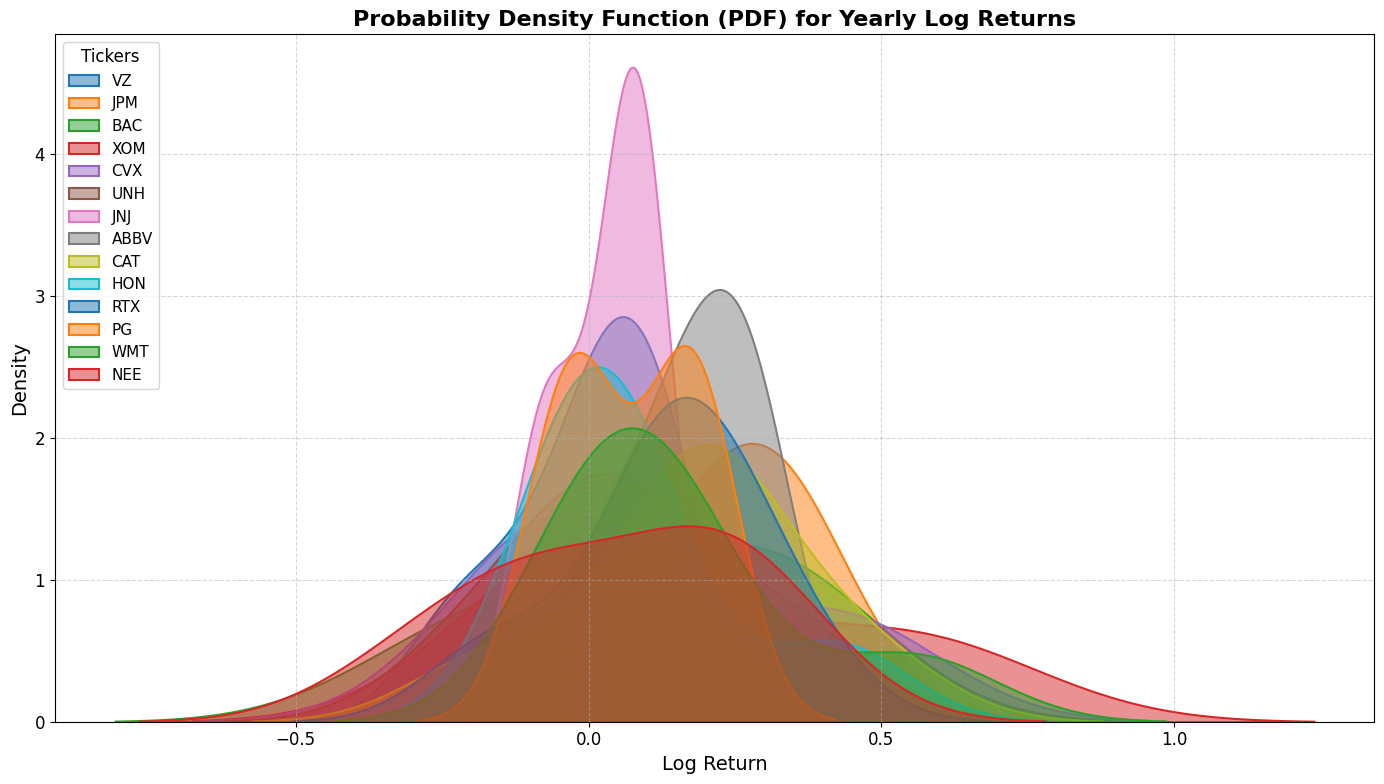

In [ ]:
# PROBABILITY DENSITY FUNCTION FOR EACH STOCK
plt.figure(figsize=(14, 8))
import seaborn as sns
colors = sns.color_palette('tab10', len(yearly_log_returns.columns))
for i, col in enumerate(yearly_log_returns.columns):
    sns.kdeplot(
        yearly_log_returns[col], label=col,
        fill=True, alpha=0.5, color=colors[i], linewidth=1.5
    )
plt.title('Probability Density Function (PDF) for Yearly Log Returns',
          fontsize=16, fontweight='bold')
plt.xlabel('Log Return', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(title='Tickers', fontsize=11, loc='upper left')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
# BUILD PDF DICT
pdf_dict = {}
for column in yearly_log_returns.columns:
    kde = gaussian_kde(yearly_log_returns[column])
    min_return   = yearly_log_returns[column].min()
    max_return   = yearly_log_returns[column].max()
    return_range = np.linspace(min_return, max_return, 1000)
    pdf_values   = kde(return_range)
    pdf_dict[column] = {'returns': return_range, 'pdf': pdf_values}


In [ ]:
# MONTE CARLO SIMULATION
num_samples = 10000

samples = np.random.multivariate_normal(
    yearly_log_returns.mean().values,
    vcv_matrix.values,
    size=num_samples
)

transformed_samples = np.zeros_like(samples)
for i, column in enumerate(yearly_log_returns.columns):
    returns   = pdf_dict[column]['returns']
    pdf       = pdf_dict[column]['pdf']
    cdf       = np.cumsum(pdf) * np.diff(returns)[0]
    for j in range(num_samples):
        sv         = samples[j, i]
        percentile = np.interp(sv, returns, cdf)
        transformed_samples[j, i] = np.interp(percentile, cdf, returns)

simulation = pd.DataFrame(transformed_samples, columns=yearly_log_returns.columns)
simulation


Ticker,VZ,JPM,BAC,XOM,CVX,UNH,JNJ,ABBV,CAT,HON,RTX,PG,WMT,NEE
0,-0.036505,0.366642,0.039276,0.082152,0.001735,-0.207718,0.108299,0.290732,0.355756,0.228012,0.178922,0.071161,0.204068,0.007165
1,-0.112289,0.037991,-0.012046,-0.059083,0.205470,0.094273,-0.051763,-0.002351,0.113753,-0.060533,-0.137216,-0.051798,0.012999,0.013051
2,-0.003870,0.141935,-0.026064,-0.064662,-0.146561,-0.117479,0.108299,0.072119,0.313640,0.040923,0.297722,-0.051798,0.080224,0.056446
3,-0.011586,0.365037,0.058998,-0.064662,-0.080710,-0.072298,0.038244,0.058195,0.211039,-0.060533,0.341900,-0.051798,0.234996,-0.016879
4,-0.005530,-0.135147,-0.272110,0.489670,0.385599,-0.207718,-0.089688,0.142716,-0.017378,-0.060533,0.070571,0.186662,0.248269,-0.250311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.091128,0.274878,0.375640,0.409388,0.322941,0.313330,-0.050182,0.194106,0.381908,-0.060533,0.326321,0.008230,0.014598,-0.203445
9996,-0.174177,0.308733,0.163423,0.315782,0.187793,0.224347,0.093051,0.290732,0.370384,0.422421,0.243358,0.027047,0.229514,0.304312
9997,-0.130245,0.062086,0.402855,0.512394,0.460347,0.257369,0.108299,0.154082,0.306557,-0.060533,0.218348,-0.045133,0.229448,0.260831
9998,-0.223414,0.173689,0.106000,0.489456,0.211916,0.107370,0.108299,0.244911,0.184599,0.071520,0.214220,0.186662,0.329399,-0.057734


In [ ]:
# BEGINNING VALUE PER STOCK
initial_value    = INITIAL_CAPITAL * EQUITY_WEIGHT
beginning_value  = OrderedDict(
    (key, value * initial_value) for key, value in weights.items()
    if key in simulation.columns
)
beginning_value_series = pd.Series(beginning_value)
print("Beginning value per stock:")
print(beginning_value_series.apply(lambda x: f'${x:,.0f}'))


Beginning value per stock:
VZ        $495,000
JPM     $3,339,270
BAC     $4,085,730
XOM     $3,291,255
CVX     $3,143,745
UNH     $4,134,240
JNJ     $4,775,760
ABBV    $4,950,000
CAT     $4,950,000
HON     $3,872,385
RTX     $4,047,615
PG      $2,718,045
WMT     $3,221,955
NEE     $2,475,000
dtype: object


In [ ]:
# ENDING PORTFOLIO VALUE
sim_aligned   = simulation[list(beginning_value.keys())]
ending_value  = (beginning_value_series * (1 + sim_aligned)).sum(axis=1)
ending_value


,0
0,5.647693e+07
1,4.981112e+07
2,5.275394e+07
3,5.342823e+07
4,5.083038e+07
...,...
9995,5.891970e+07
9996,6.157351e+07
9997,6.019538e+07
9998,5.833661e+07


In [ ]:
# VALUE AT RISK
def calculate_var(ending_value, alpha=0.05):
    ranked = ending_value.rank(pct=True)
    return ending_value[ranked <= alpha].max()

VaR_95_value = calculate_var(ending_value, 0.05)
VaR_99_value = calculate_var(ending_value, 0.01)

print(f"VaR at 95% confidence level (5th percentile) : ${VaR_95_value:,.2f}")
print(f"VaR at 99% confidence level (1st percentile) : ${VaR_99_value:,.2f}")


VaR at 95% confidence level (5th percentile) : $50,083,675.39
VaR at 99% confidence level (1st percentile) : $48,276,597.89


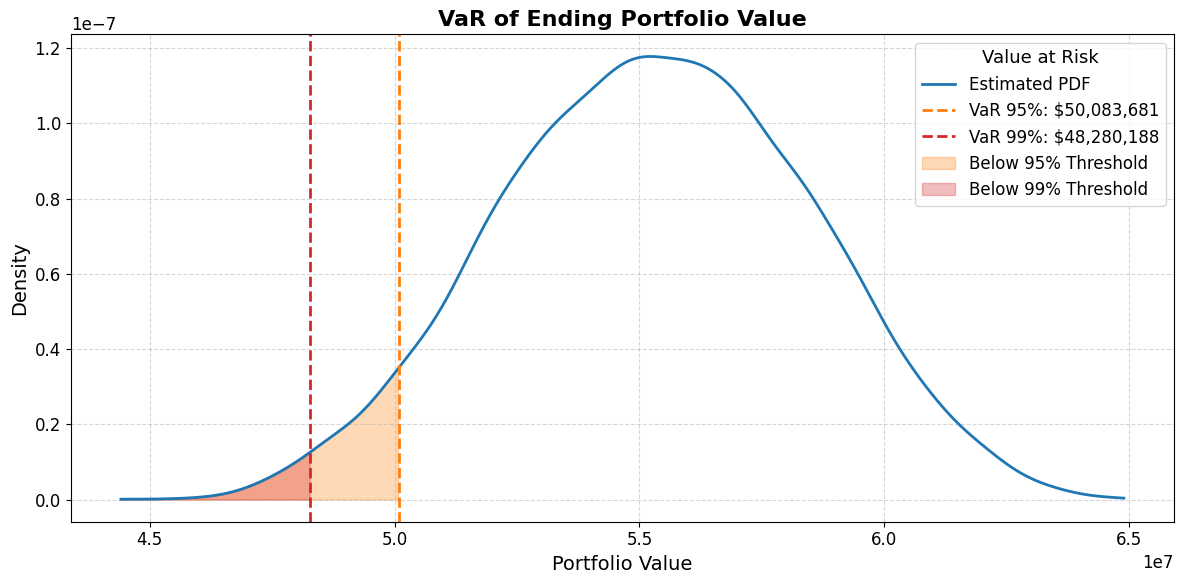

In [ ]:
# VAR DISTRIBUTION PLOT
from scipy.stats import gaussian_kde as gkde
sorted_vals = ending_value.sort_values()
kde_var     = stats.gaussian_kde(sorted_vals)
x_var       = np.linspace(sorted_vals.min(), sorted_vals.max(), 1000)
pdf_vals    = kde_var(x_var)

VaR_95_thr = sorted_vals.quantile(0.05)
VaR_99_thr = sorted_vals.quantile(0.01)

plt.figure(figsize=(12, 6))
plt.plot(x_var, pdf_vals, label='Estimated PDF', color='#1f77b4', linewidth=2)
plt.axvline(VaR_95_thr, color='#ff7f0e', linestyle='--', linewidth=2,
            label=f'VaR 95%: ${VaR_95_thr:,.0f}')
plt.axvline(VaR_99_thr, color='#d62728', linestyle='--', linewidth=2,
            label=f'VaR 99%: ${VaR_99_thr:,.0f}')
plt.fill_between(x_var, pdf_vals, 0, where=(x_var <= VaR_95_thr),
                 color='#ff7f0e', alpha=0.3, label='Below 95% Threshold')
plt.fill_between(x_var, pdf_vals, 0, where=(x_var <= VaR_99_thr),
                 color='#d62728', alpha=0.3, label='Below 99% Threshold')
plt.title('VaR of Ending Portfolio Value', fontsize=16, fontweight='bold')
plt.xlabel('Portfolio Value', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.grid(linestyle='--', alpha=0.5)
plt.legend(fontsize=12, title='Value at Risk', title_fontsize=13)
plt.tight_layout()
plt.show()


# **Section 3: Monitoring & Rebalancing**

In [ ]:
# INITIAL PORTFOLIO
equity_capital = INITIAL_CAPITAL * EQUITY_WEIGHT
cash_capital   = INITIAL_CAPITAL * CASH_WEIGHT

first_day = prices_mgmt.index[0]
first_prices = prices_mgmt.loc[first_day]

holdings = {}
weights_target = {}

for ticker, w in weights.items():
    if ticker not in first_prices or np.isnan(first_prices[ticker]):
        continue
    alloc  = equity_capital * w / sum(weights.values())
    shares = int(alloc // first_prices[ticker])
    holdings[ticker]       = shares
    weights_target[ticker] = w / sum(weights.values())

invested = sum(holdings[t] * first_prices[t] for t in holdings)
remaining_cash = INITIAL_CAPITAL - invested

print(f"Portfolio Initialisation ({first_day.date()})")
print(f"{'='*50}")
print(f"Total Capital      : ${INITIAL_CAPITAL:>15,.2f}")
print(f"Equity Invested    : ${invested:>15,.2f}  ({invested/INITIAL_CAPITAL:.2%})")
print(f"Cash (residual)    : ${remaining_cash:>15,.2f}  ({remaining_cash/INITIAL_CAPITAL:.2%})")
print(f"Number of Stocks   : {len(holdings)}")
print(f"\nInitial Holdings:")
for t, s in sorted(holdings.items()):
    print(f"  {t:6s}: {s:>8,} shares @ ${first_prices[t]:>8.2f}  = ${s*first_prices[t]:>12,.2f}")

Portfolio Initialisation (2025-05-01)
Total Capital      : $  50,000,000.00
Equity Invested    : $  49,499,208.75  (99.00%)
Cash (residual)    : $     500,791.25  (1.00%)
Number of Stocks   : 14

Initial Holdings:
  ABBV  :   25,602 shares @ $  193.34  = $4,949,890.59
  BAC   :  101,710 shares @ $   40.17  = $4,085,690.51
  CAT   :   15,766 shares @ $  313.96  = $4,949,893.23
  CVX   :   23,071 shares @ $  136.26  = $3,143,654.33
  HON   :   19,496 shares @ $  198.62  = $3,872,372.47
  JNJ   :   30,919 shares @ $  154.46  = $4,775,748.95
  JPM   :   13,525 shares @ $  246.89  = $3,339,187.24
  NEE   :   37,471 shares @ $   66.05  = $2,474,959.66
  PG    :   16,989 shares @ $  159.98  = $2,717,900.15
  RTX   :   31,768 shares @ $  127.41  = $4,047,561.00
  UNH   :   10,318 shares @ $  400.68  = $4,134,216.16
  VZ    :   11,431 shares @ $   43.30  = $  494,962.29
  WMT   :   33,076 shares @ $   97.41  = $3,221,933.28
  XOM   :   31,114 shares @ $  105.78  = $3,291,238.88


In [ ]:
INITIAL_PURCHASE_SALES_CHARGE_RATE = 0.04

# REBALANCING
initial_sales_charge_rebal = (
    sum(holdings.get(t, 0) * prices_mgmt.iloc[0].get(t, 0) for t in holdings)
    * INITIAL_PURCHASE_SALES_CHARGE_RATE
)

rebalance_records = []
current_holdings = holdings.copy()
current_cash = remaining_cash - initial_sales_charge_rebal

rebalanced_port_values_list = []

for date, row in prices_mgmt.iterrows():
    if row.isnull().all():
        # Use last known value for missing-data days; still only one append
        prev_val = rebalanced_port_values_list[-1]['Rebalanced Portfolio Value'] if rebalanced_port_values_list else current_cash
        rebalanced_port_values_list.append({'Date': date, 'Rebalanced Portfolio Value': prev_val})
        continue

    # Step 1: Process Dividends and Reinvest
    dividends_on_date = dividends_mgmt.loc[date]
    if not dividends_on_date.empty:
        for ticker, div_per_share in dividends_on_date.items():
            if div_per_share > 0 and ticker in current_holdings and current_holdings[ticker] > 0:
                dividend_value = div_per_share * current_holdings[ticker]
                stock_price = row.get(ticker, np.nan)
                if not np.isnan(stock_price) and stock_price > 0:
                    shares_bought = int(dividend_value // stock_price)
                    current_holdings[ticker] += shares_bought
                    current_cash += (dividend_value - shares_bought * stock_price)
                else:
                    current_cash += dividend_value

    # Step 2: Calculate end-of-day portfolio value (single append per day) [FIX 3]
    total_val = sum(current_holdings.get(t, 0) * row.get(t, np.nan) for t in current_holdings
                    if not np.isnan(row.get(t, np.nan))) + current_cash

    rebalanced_port_values_list.append({'Date': date, 'Rebalanced Portfolio Value': total_val})


    # Step 3: Determine if Rebalancing is Needed
    actual_weights = {}
    if total_val > 0:
        for t in current_holdings:
            p = row.get(t, np.nan)
            if not np.isnan(p):
                actual_weights[t] = (current_holdings[t] * p) / total_val
            else:
                actual_weights[t] = 0
    else:
        for t in current_holdings:
            actual_weights[t] = 0

    needs_rebalance = False
    for t, tw in weights_target.items():
        aw = actual_weights.get(t, 0)
        if abs(aw - tw) > REBALANCE_THRESHOLD:
            needs_rebalance = True
            break
        elif tw == 0 and aw > 0 and aw > REBALANCE_THRESHOLD:
            needs_rebalance = True
            break

    # Step 4: Perform Rebalancing if Needed
    if needs_rebalance:
        current_date = date.date()
        daily_rebalance_records = []

        # 4a. Calculate target number of shares for each stock
        equity_capital_for_rebalance = total_val * EQUITY_WEIGHT
        temp_target_shares = {}
        for t, tw in weights_target.items():
            p = row.get(t, np.nan)
            if not np.isnan(p) and p > 0:
                target_stock_value = equity_capital_for_rebalance * tw
                temp_target_shares[t] = int(target_stock_value // p)
            else:
                temp_target_shares[t] = current_holdings.get(t, 0)

        # 4b. Identify Sells and execute them, adding cash
        all_stocks_involved = set(current_holdings.keys()).union(set(weights_target.keys()))

        holdings_before_rebalance_today = current_holdings.copy()

        for t in all_stocks_involved:
            current_sh = current_holdings.get(t, 0)
            target_sh = temp_target_shares.get(t, 0)
            p = row.get(t, np.nan)

            if np.isnan(p) or p <= 0:
                continue

            if current_sh > target_sh:
                shares_to_sell = current_sh - target_sh
                current_cash += shares_to_sell * p
                current_holdings[t] = target_sh

                daily_rebalance_records.append({
                    'Date':                      current_date,
                    'Stock':                     t,
                    'Weight before rebalancing': actual_weights.get(t, 0),
                    'Buy / Sell':                'Sell',
                    'No. of stocks to buy/sell': shares_to_sell,
                    'Weight after rebalancing':  0
                })

        # 4c. Identify Buys and execute them using available cash
        buy_orders = []
        for t in all_stocks_involved:
            current_sh = current_holdings.get(t, 0)
            target_sh = temp_target_shares.get(t, 0)
            p = row.get(t, np.nan)

            if np.isnan(p) or p <= 0:
                continue

            if current_sh < target_sh:
                shares_to_buy_requested = target_sh - current_sh
                buy_orders.append({'ticker': t, 'shares_requested': shares_to_buy_requested, 'price': p})

        buy_orders.sort(key=lambda x: weights_target.get(x['ticker'], 0), reverse=True)

        for order in buy_orders:
            t = order['ticker']
            shares_requested = order['shares_requested']
            p = order['price']

            cost_needed = shares_requested * p
            if current_cash >= cost_needed:
                current_holdings[t] += shares_requested
                current_cash -= cost_needed
                daily_rebalance_records.append({
                    'Date':                      current_date,
                    'Stock':                     t,
                    'Weight before rebalancing': actual_weights.get(t, 0),
                    'Buy / Sell':                'Buy',
                    'No. of stocks to buy/sell': shares_requested,
                    'Weight after rebalancing':  0
                })
            else:
                shares_can_buy = int(current_cash // p)
                if shares_can_buy > 0:
                    current_holdings[t] += shares_can_buy
                    current_cash -= shares_can_buy * p
                    daily_rebalance_records.append({
                        'Date':                      current_date,
                        'Stock':                     t,
                        'Weight before rebalancing': actual_weights.get(t, 0),
                        'Buy / Sell':                'Buy',
                        'No. of stocks to buy/sell': shares_can_buy,
                        'Weight after rebalancing':  0
                    })

        # 4d. Calculate final weights for logging (Weight after rebalancing)
        total_val_after_rebalance = sum(current_holdings.get(t, 0) * row.get(t, np.nan) for t in current_holdings if not np.isnan(row.get(t, np.nan))) + current_cash

        final_daily_rebalance_records = []
        for record in daily_rebalance_records:
            t = record['Stock']
            adjusted_shares = current_holdings.get(t, 0)
            p = row.get(t, np.nan)

            original_shares_for_log = holdings_before_rebalance_today.get(t, 0)
            shares_changed = abs(adjusted_shares - original_shares_for_log)

            if shares_changed > 0:
                record['No. of stocks to buy/sell'] = shares_changed
                if adjusted_shares > original_shares_for_log:
                    record['Buy / Sell'] = 'Buy'
                elif adjusted_shares < original_shares_for_log:
                    record['Buy / Sell'] = 'Sell'

                if not np.isnan(p) and total_val_after_rebalance > 0:
                    record['Weight after rebalancing'] = (adjusted_shares * p) / total_val_after_rebalance
                else:
                    record['Weight after rebalancing'] = 0

                final_daily_rebalance_records.append(record)
            else:

                pass

        rebalance_records.extend(final_daily_rebalance_records)


rebalanced_port_value_df = pd.DataFrame(rebalanced_port_values_list).set_index('Date')

rebalance_df = pd.DataFrame(rebalance_records)

print("Portfolio Rebalancing Events (months where drift ≥ 5% occurred)")
if rebalance_df.empty:
    print("No rebalancing events occurred during the management period.")
else:
    display_rb = rebalance_df.copy()
    display_rb['Weight before rebalancing'] = display_rb['Weight before rebalancing'].map('{:.2%}'.format)
    display_rb['Weight after rebalancing']  = display_rb['Weight after rebalancing'].map('{:.2%}'.format)
    from IPython.display import display as ipy_display
    ipy_display(display_rb)

Portfolio Rebalancing Events (months where drift ≥ 5% occurred)


,Date,Stock,Weight before rebalancing,Buy / Sell,No. of stocks to buy/sell,Weight after rebalancing
0,2025-10-29,CAT,15.66%,Sell,5834,9.90%
1,2025-10-29,JPM,7.03%,Sell,681,6.68%
2,2025-10-29,JNJ,9.88%,Sell,1034,9.55%
3,2025-10-29,RTX,9.53%,Sell,4832,8.10%
4,2025-10-29,BAC,9.11%,Sell,10648,8.17%
5,2025-10-29,NEE,5.25%,Sell,2142,4.95%
6,2025-10-29,ABBV,9.87%,Buy,80,9.90%
7,2025-10-29,UNH,6.26%,Buy,3353,8.27%
8,2025-10-29,HON,6.66%,Buy,3209,7.74%
9,2025-10-29,XOM,6.22%,Buy,1856,6.58%



Monthly Returns Summary (with and without Dividend Reinvestment/Rebalancing, with Fees):
  2025-05: Base +1.80% | Unrebalanced DR +2.13% | Rebalanced DR +2.13% | DJIA +3.72%
  2025-06: Base +3.68% | Unrebalanced DR +3.82% | Rebalanced DR +3.82% | DJIA +4.32%
  2025-07: Base +2.13% | Unrebalanced DR +2.34% | Rebalanced DR +2.34% | DJIA +0.08%
  2025-08: Base +4.02% | Unrebalanced DR +4.38% | Rebalanced DR +4.38% | DJIA +3.20%
  2025-09: Base +4.76% | Unrebalanced DR +4.84% | Rebalanced DR +4.84% | DJIA +1.87%
  2025-10: Base +3.56% | Unrebalanced DR +3.74% | Rebalanced DR +3.59% | DJIA +2.51%
  2025-11: Base +1.34% | Unrebalanced DR +1.64% | Rebalanced DR +1.49% | DJIA +0.32%
  2025-12: Base +0.76% | Unrebalanced DR +0.86% | Rebalanced DR +0.72% | DJIA +0.73%
  2026-01: Base +6.89% | Unrebalanced DR +7.09% | Rebalanced DR +6.18% | DJIA +1.73%
  2026-02: Base +5.74% | Unrebalanced DR +6.02% | Rebalanced DR +5.55% | DJIA +0.17%
  2026-03: Base -2.46% | Unrebalanced DR -2.34% | Rebalanced

<Figure size 1500x700 with 0 Axes>

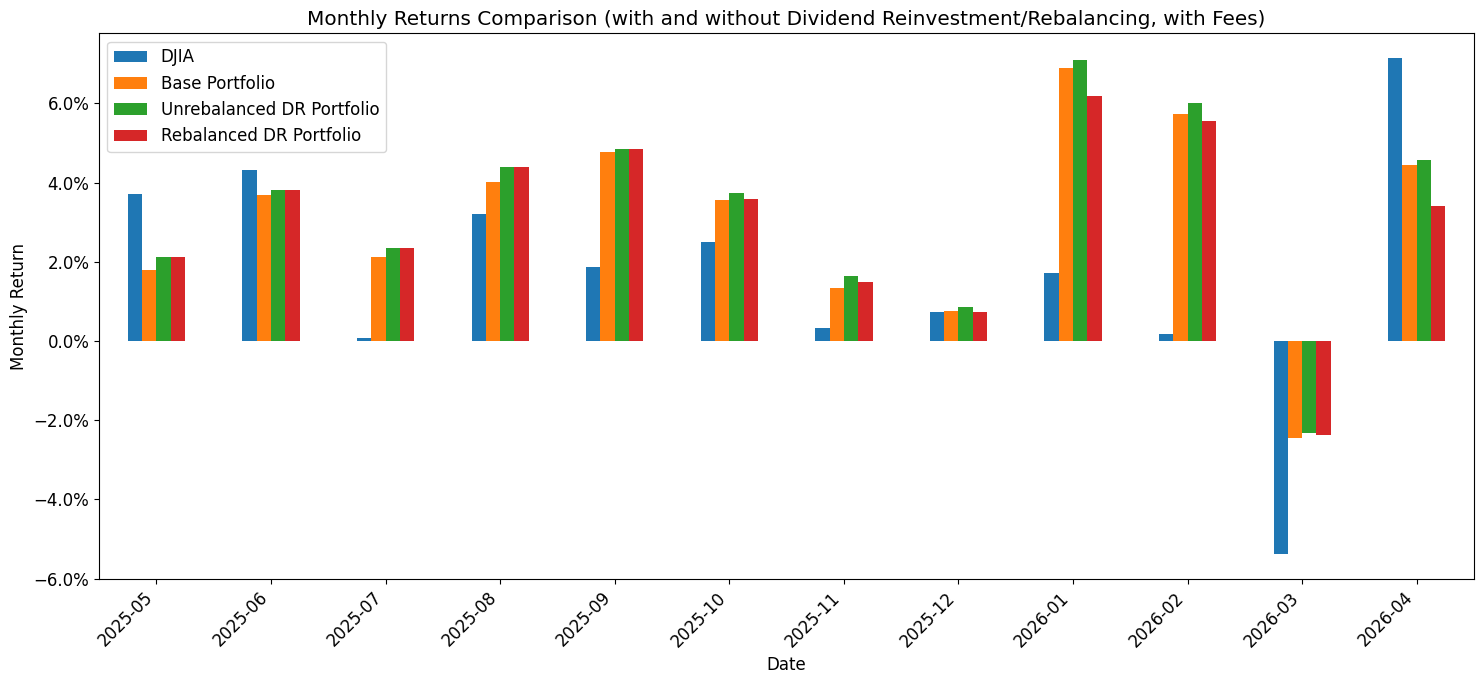

In [ ]:
# MONTHLY RETURNS
monthly_prices_mgmt = prices_mgmt.resample('ME').last()

# FEES
ANNUAL_OPERATING_EXPENSE_RATE = 0.011
INITIAL_PURCHASE_SALES_CHARGE_RATE = 0.04
DIVIDEND_REINVESTMENT_FEE_RATE = 0.01
REDEMPTION_FEE_RATE = 0.01
TRADING_DAYS_IN_YEAR = 252

initial_invested_value_before_fee = sum(holdings.get(t, 0) * prices_mgmt.iloc[0].get(t, 0) for t in holdings)
initial_sales_charge = initial_invested_value_before_fee * INITIAL_PURCHASE_SALES_CHARGE_RATE
initial_effective_capital = INITIAL_CAPITAL - initial_sales_charge

# Scenario 1: Base Portfolio
base_port_values = []
initial_holdings_base = holdings.copy()
initial_remaining_cash_base = remaining_cash - initial_sales_charge # Deduct initial sales charge for this scenario's starting point

for date, row in monthly_prices_mgmt.iterrows():
    val = sum(initial_holdings_base.get(t, 0) * row.get(t, 0) for t in initial_holdings_base) + initial_remaining_cash_base

    daily_operating_expense = val * (ANNUAL_OPERATING_EXPENSE_RATE / TRADING_DAYS_IN_YEAR)

    val -= daily_operating_expense

    base_port_values.append({'Date': date, 'Base Portfolio Value': val})

base_port_value_df = pd.DataFrame(base_port_values).set_index('Date')

may_end_base_value = base_port_value_df.loc[base_port_value_df.index.to_period('M') == pd.Period('2025-05', freq='M')].iloc[-1]['Base Portfolio Value']
may_return_base = pd.Series([(may_end_base_value - initial_effective_capital) / initial_effective_capital], index=[pd.Period('2025-05', freq='M')])

subsequent_base_returns = base_port_value_df['Base Portfolio Value'].pct_change().dropna()
subsequent_base_returns.index = subsequent_base_returns.index.to_period('M')
base_port_monthly_returns = pd.concat([may_return_base, subsequent_base_returns])


# Scenario 2: Unrebalanced Portfolio with Dividend Reinvestment
current_holdings_unrebal = holdings.copy()
current_cash_unrebal = remaining_cash - initial_sales_charge # Deduct initial sales charge here as well for this scenario's starting point

unrebalanced_dr_port_values_list = []

for date, row in prices_mgmt.iterrows():
    if row.isnull().all():
        total_val_unrebal = unrebalanced_dr_port_values_list[-1]['Unrebalanced DR Portfolio Value'] if unrebalanced_dr_port_values_list else current_cash_unrebal
        daily_operating_expense_unrebal = total_val_unrebal * (ANNUAL_OPERATING_EXPENSE_RATE / TRADING_DAYS_IN_YEAR)

        total_val_unrebal -= daily_operating_expense_unrebal
        unrebalanced_dr_port_values_list.append({'Date': date, 'Unrebalanced DR Portfolio Value': total_val_unrebal})
        continue

    dividends_on_date = dividends_mgmt.loc[date]
    if not dividends_on_date.empty:
        for ticker, div_per_share in dividends_on_date.items():
            if div_per_share > 0 and ticker in current_holdings_unrebal and current_holdings_unrebal[ticker] > 0:
                dividend_value = div_per_share * current_holdings_unrebal[ticker]
                dividend_value_after_fee = dividend_value * (1 - DIVIDEND_REINVESTMENT_FEE_RATE)

                stock_price = row.get(ticker, np.nan)
                if not np.isnan(stock_price) and stock_price > 0:
                    shares_bought = int(dividend_value_after_fee // stock_price)
                    current_holdings_unrebal[ticker] += shares_bought
                    current_cash_unrebal += (dividend_value_after_fee - shares_bought * stock_price)
                else:
                    current_cash_unrebal += dividend_value_after_fee

    total_val_unrebal = sum(current_holdings_unrebal.get(t, 0) * row.get(t, np.nan) for t in current_holdings_unrebal
                            if not np.isnan(row.get(t, np.nan))) + current_cash_unrebal

    daily_operating_expense_unrebal = total_val_unrebal * (ANNUAL_OPERATING_EXPENSE_RATE / TRADING_DAYS_IN_YEAR)


    total_val_unrebal -= daily_operating_expense_unrebal
    unrebalanced_dr_port_values_list.append({'Date': date, 'Unrebalanced DR Portfolio Value': total_val_unrebal})

unrebalanced_dr_port_value_df = pd.DataFrame(unrebalanced_dr_port_values_list).set_index('Date')

may_end_unrebal_value = unrebalanced_dr_port_value_df.loc[unrebalanced_dr_port_value_df.index.to_period('M') == pd.Period('2025-05', freq='M')].iloc[-1]['Unrebalanced DR Portfolio Value']
may_return_unrebal = pd.Series([(may_end_unrebal_value - initial_effective_capital) / initial_effective_capital], index=[pd.Period('2025-05', freq='M')])

subsequent_unrebal_returns = unrebalanced_dr_port_value_df['Unrebalanced DR Portfolio Value'].resample('ME').last().pct_change().dropna()
subsequent_unrebal_returns.index = subsequent_unrebal_returns.index.to_period('M')
unrebalanced_dr_port_monthly_returns = pd.concat([may_return_unrebal, subsequent_unrebal_returns])


# Scenario 3: Rebalanced Portfolio with Dividend Reinvestment
if 'rebalanced_port_value_df' in locals() and not rebalanced_port_value_df.empty:
    daily_expense_rate = ANNUAL_OPERATING_EXPENSE_RATE / TRADING_DAYS_IN_YEAR
    nav = rebalanced_port_value_df['Rebalanced Portfolio Value'].copy()
    nav = nav * (1 - daily_expense_rate) ** np.arange(1, len(nav) + 1)
    rebalanced_port_value_df_with_fees = nav.to_frame()

    may_end_rebal_value = rebalanced_port_value_df_with_fees.loc[rebalanced_port_value_df_with_fees.index.to_period('M') == pd.Period('2025-05', freq='M')].iloc[-1]['Rebalanced Portfolio Value']
    may_return_rebal = pd.Series([(may_end_rebal_value - initial_effective_capital) / initial_effective_capital], index=[pd.Period('2025-05', freq='M')])

    subsequent_rebal_returns = rebalanced_port_value_df_with_fees['Rebalanced Portfolio Value'].resample('ME').last().pct_change().dropna()
    subsequent_rebal_returns.index = subsequent_rebal_returns.index.to_period('M')

    rebalanced_dr_port_monthly_returns_original = pd.concat([may_return_rebal, subsequent_rebal_returns])

    first_rebalance_month = pd.Period('2025-10', freq='M')

    rebalanced_dr_port_monthly_returns = pd.Series(dtype='float64')

    pre_rebalance_months = unrebalanced_dr_port_monthly_returns.index[unrebalanced_dr_port_monthly_returns.index < first_rebalance_month]
    rebalanced_dr_port_monthly_returns = pd.concat([rebalanced_dr_port_monthly_returns, unrebalanced_dr_port_monthly_returns.loc[pre_rebalance_months]])

    post_rebalance_months = rebalanced_dr_port_monthly_returns_original.index[rebalanced_dr_port_monthly_returns_original.index >= first_rebalance_month]
    rebalanced_dr_port_monthly_returns = pd.concat([rebalanced_dr_port_monthly_returns, rebalanced_dr_port_monthly_returns_original.loc[post_rebalance_months]])

else:
    print("Warning: rebalanced_port_value_df not found or is empty. Rebalanced portfolio returns will not be calculated.")
    rebalanced_dr_port_monthly_returns = pd.Series(dtype='float64')


# Benchmark: DJIA Returns
# Consistent method: every month's return is derived from cumulative return vs day-one start price.
# This mirrors the May logic exactly: (month_end_price - start_price) / start_price for May,
# then chain into monthly returns: r_t = (1+cum_t)/(1+cum_{t-1}) - 1 for subsequent months.
djia_start_price = djia_prices.iloc[0]
djia_monthly_end_prices = djia_prices.resample('ME').last()

# Cumulative return up to end of each month from day-one start price
djia_cum_returns = djia_monthly_end_prices / djia_start_price - 1

# Convert cumulative to monthly: r_t = (1+cum_t)/(1+cum_{t-1}) - 1
# For the first month this reduces exactly to (price_end_may - start_price) / start_price
djia_cum_shifted = djia_cum_returns.shift(1).fillna(0)
djia_monthly_raw = (1 + djia_cum_returns) / (1 + djia_cum_shifted) - 1
djia_monthly_raw.index = djia_monthly_raw.index.to_period('M')
djia_monthly = djia_monthly_raw


all_monthly_returns = pd.DataFrame({
    'DJIA': djia_monthly,
    'Base Portfolio': base_port_monthly_returns,
    'Unrebalanced DR Portfolio': unrebalanced_dr_port_monthly_returns,
    'Rebalanced DR Portfolio': rebalanced_dr_port_monthly_returns
}).dropna()

print("\nMonthly Returns Summary (with and without Dividend Reinvestment/Rebalancing, with Fees):")
for index, row in all_monthly_returns.iterrows():
    print(f"  {index}: Base {row['Base Portfolio']:+.2%} | Unrebalanced DR {row['Unrebalanced DR Portfolio']:+.2%} | Rebalanced DR {row['Rebalanced DR Portfolio']:+.2%} | DJIA {row['DJIA']:+.2%}")

# Plotting monthly returns
plt.figure(figsize=(15, 7))
all_monthly_returns.plot(kind='bar', figsize=(15, 7))
plt.title('Monthly Returns Comparison (with and without Dividend Reinvestment/Rebalancing, with Fees)')
plt.ylabel('Monthly Return')
plt.xlabel('Date')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

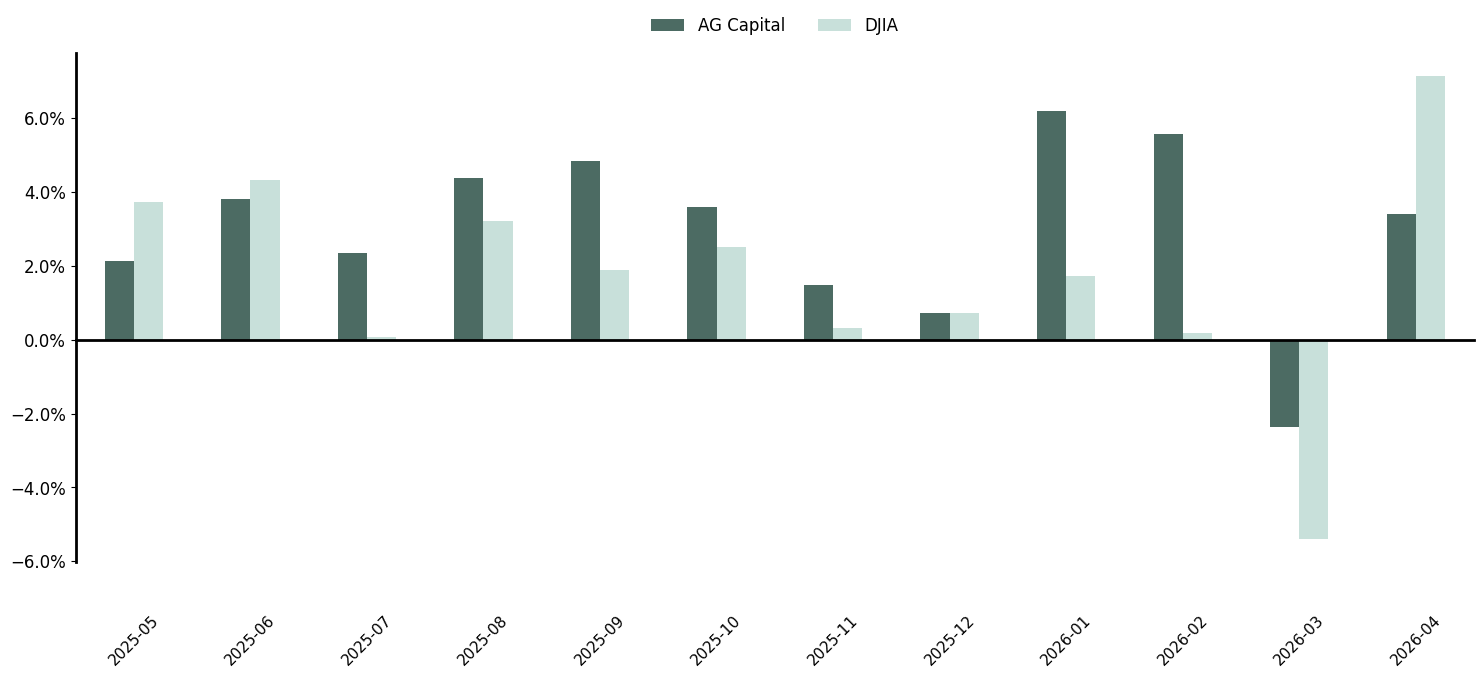

In [ ]:
# MONTHLY RETURNS GRAPH
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

fig, ax = plt.subplots(figsize=(15, 7))

plot_data = all_monthly_returns[['Rebalanced DR Portfolio', 'DJIA']].copy()
plot_data = plot_data.rename(columns={'Rebalanced DR Portfolio': 'AG Capital'})
colors = ['#4c6b63', '#c8e0da']

plot_data.plot(kind='bar', ax=ax, color=colors)

ax.set_xlabel('')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax.tick_params(axis='x', labelbottom=False, bottom=False)

ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_position(('data', 0))
ax.spines['left'].set_visible(True)

min_y_val = plot_data.min().min()

x_positions = np.arange(len(plot_data.index))
for i, date_period in enumerate(plot_data.index):
    label_text = date_period.strftime('%Y-%m')
    ax.text(x_positions[i], min_y_val - 0.02, label_text,
            ha='center', va='top', rotation=45, color='black',
            fontsize=11)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=len(plot_data.columns), frameon=False)

plt.tight_layout()
plt.show()

# **Section 4: Performance & Evaluation**

## **MEASUREMENT**

In [ ]:
#DAILY RETURNS

ANNUAL_OUTPERFORMANCE_FEE_RATE = 0.003

daily_outperformance_fee = (1 + ANNUAL_OUTPERFORMANCE_FEE_RATE)**(1/TRADING_DAYS_IN_YEAR) - 1


port_daily = rebalanced_port_value_df_with_fees['Rebalanced Portfolio Value'].pct_change().dropna()


djia_returns_aligned_pre = djia_returns.reindex(port_daily.index).fillna(0)
outperform_days = (port_daily > djia_returns_aligned_pre)
port_daily = port_daily - daily_outperformance_fee * outperform_days.astype(float)


common_idx    = port_daily.index.intersection(djia_returns.index)
port_daily_a  = port_daily.loc[common_idx]
djia_daily_a  = djia_returns.loc[common_idx]

print(f"Aligned daily returns: {len(common_idx)} trading days")
print(f"Period: {common_idx[0].date()} → {common_idx[-1].date()}")

Aligned daily returns: 250 trading days
Period: 2025-05-02 → 2026-04-30


In [ ]:
#PORTFOLIO PERFORMANCE
rf_daily = risk_free_rate / 252
excess_port  = port_daily_a - rf_daily
excess_bench = djia_daily_a - rf_daily

X_reg = sm.add_constant(excess_bench)
reg   = sm.OLS(excess_port, X_reg).fit()
beta  = reg.params.iloc[1]
alpha = reg.params.iloc[0]

total_risk    = port_daily.std() * np.sqrt(252)
market_risk   = beta * djia_daily_a.std() * np.sqrt(252)
specific_risk = np.sqrt(max(total_risk**2 - market_risk**2, 0))

num_trading_days = len(port_daily_a)
num_years = num_trading_days / TRADING_DAYS_IN_YEAR

start_portfolio_value = initial_effective_capital
end_portfolio_value   = rebalanced_port_value_df_with_fees.loc[port_daily_a.index[-1]]['Rebalanced Portfolio Value']
total_return_port     = (end_portfolio_value / start_portfolio_value) - 1
ann_ret_port = (1 + total_return_port)**(1 / num_years) - 1

num_bench_days  = len(djia_prices)
num_bench_years = num_bench_days / TRADING_DAYS_IN_YEAR
bench_total_ret = (djia_prices.iloc[-1] / djia_prices.iloc[0]) - 1
ann_ret_bench   = (1 + bench_total_ret)**(1 / num_bench_years) - 1
ann_std_port  = total_risk
ann_alpha     = alpha * 252


sharpe_p   = (ann_ret_port  - risk_free_rate) / ann_std_port
treynor_p  = (ann_ret_port  - risk_free_rate) / beta
bench_std  = djia_daily_a.std() * np.sqrt(252)
m2         = sharpe_p * bench_std + risk_free_rate
t2         = treynor_p - (ann_ret_bench - risk_free_rate) / 1.0

tracking_err  = (port_daily_a - djia_daily_a).std() * np.sqrt(252)
active_return = ann_ret_port - ann_ret_bench
info_ratio    = active_return / tracking_err if tracking_err != 0 else np.nan


cum_ret  = (1 + port_daily_a).cumprod()
roll_max = cum_ret.cummax()
drawdown = (cum_ret - roll_max) / roll_max
max_dd   = drawdown.min()


perf_table = pd.DataFrame({
    'Metric': [
        'Beta', 'Intercept (daily α)', 'Total Risk (ann.)', 'Market Risk (ann.)',
        'Specific Risk (ann.)', 'Annualised Return', 'Annualised Std Dev',
        "Jensen's Alpha (ann.)", 'Sharpe Ratio', 'Treynor Ratio',
        'M² Measure', 'T² Measure', 'Information Ratio', 'Maximum Drawdown'
    ],
    'Portfolio': [
        f'{beta:.2f}', f'{alpha:.2f}', f'{total_risk:.2%}',
        f'{market_risk:.2%}', f'{specific_risk:.2%}',
        f'{ann_ret_port:.2%}', f'{ann_std_port:.2%}',
        f'{ann_alpha:.2%}', f'{sharpe_p:.2f}', f'{treynor_p:.2f}',
        f'{m2:.2%}', f'{t2:.2%}', f'{info_ratio:.2f}', f'{max_dd:.2%}'
    ],
    'Benchmark (DJIA)': [
        '1.00', '0.00',
        f'{bench_std:.2%}', f'{bench_std:.2%}',
        '0.00%', f'{ann_ret_bench:.2%}', f'{bench_std:.2%}',
        '—', f'{(ann_ret_bench - risk_free_rate)/bench_std:.2f}',
        f'{(ann_ret_bench - risk_free_rate)/1:.2f}', '—', '—', '—',
        f'{((1+djia_daily_a).cumprod() / (1+djia_daily_a).cumprod().cummax() - 1).min():.2%}'
    ]
})

print("Portfolio Performance Summary")
from IPython.display import display as ipy_display
ipy_display(perf_table)

Portfolio Performance Summary


,Metric,Portfolio,Benchmark (DJIA)
0,Beta,0.66,1.00
1,Intercept (daily α),0.00,0.00
2,Total Risk (ann.),11.13%,12.59%
3,Market Risk (ann.),8.25%,12.59%
4,Specific Risk (ann.),7.47%,0.00%
5,Annualised Return,42.06%,21.93%
6,Annualised Std Dev,11.13%,12.59%
7,Jensen's Alpha (ann.),20.43%,—
8,Sharpe Ratio,3.36,1.37
9,Treynor Ratio,0.57,0.17


## **ATTRIBUTION**

In [ ]:
# ASSET CLASS ALLOCATION ANALYSIS
bench_eq_wt   = 1.00
bench_cash_wt = 0.00

port_eq_wt    = EQUITY_WEIGHT
port_cash_wt  = CASH_WEIGHT

equity_return  = ann_ret_port  / EQUITY_WEIGHT
cash_return    = risk_free_rate

bench_return   = ann_ret_bench
bench_eq_ret   = bench_return

asset_class_df = pd.DataFrame({
    'Asset Class':    ['Equity', 'Cash'],
    'Portfolio Weight': [port_eq_wt, port_cash_wt],
    'Index Weight':   [bench_eq_wt, bench_cash_wt],
    'Excess Weight':  [port_eq_wt - bench_eq_wt, port_cash_wt - bench_cash_wt],
    'Index Return':   [bench_eq_ret, 0.0],
    'Contribution':   [
        (port_eq_wt  - bench_eq_wt)  * bench_eq_ret,
        (port_cash_wt - bench_cash_wt) * 0.0
    ]
})

display_ac = asset_class_df.copy()

for col in ['Portfolio Weight', 'Index Weight', 'Excess Weight', 'Index Return', 'Contribution']:
    display_ac[col] = display_ac[col].map('{:.2%}'.format)

print("Asset Class Allocation Analysis")
print("=" * 75)
ipy_display(display_ac)

Asset Class Allocation Analysis


,Asset Class,Portfolio Weight,Index Weight,Excess Weight,Index Return,Contribution
0,Equity,99.00%,100.00%,-1.00%,21.93%,-0.22%
1,Cash,1.00%,0.00%,1.00%,0.00%,0.00%


In [ ]:
# SECTOR ALLOCATION & STOCK SELECTION ANALYSIS

djia_sector_weights = {
    "Communication Services": 0.02,
    "Financials":             0.13,
    "Energy":                 0.10,
    "Healthcare":             0.28,
    "Industrials":            0.31,
    "Consumer Staples":       0.12,
    "Utilities":              0.03
}

daily_returns_mgmt = prices_mgmt.pct_change().dropna()

port_sector_weights = {}
for sector, tickers_s in tickers_dict.items():
    w = sum(weights.get(t, 0) for t in tickers_s) * EQUITY_WEIGHT
    port_sector_weights[sector] = w

sector_returns_port = {}
for sector, tickers_s in tickers_dict.items():
    rets = []
    for t in tickers_s:
        if t in prices_mgmt.columns:
            p = prices_mgmt[t].dropna()
            if len(p) >= 2:
                cagr = (p.iloc[-1] / p.iloc[0]) ** (252 / len(p)) - 1
                rets.append(cagr)
    sector_returns_port[sector] = float(np.mean(rets)) if rets else 0.0


SECTOR_ETF_MAP = {
    "Communication Services": "XLC",
    "Financials":             "XLF",
    "Energy":                 "XLE",
    "Healthcare":             "XLV",
    "Industrials":            "XLI",
    "Consumer Staples":       "XLP",
    "Utilities":              "XLU",
}

try:
    import yfinance as yf
    etf_tickers  = list(SECTOR_ETF_MAP.values())
    etf_raw      = yf.download(etf_tickers, start=MGMT_START, end=MGMT_END,
                               auto_adjust=True, progress=False)
    if isinstance(etf_raw.columns, pd.MultiIndex):
        etf_prices = etf_raw["Close"]
    else:
        etf_prices = etf_raw[["Close"]]

    etf_prices.ffill(inplace=True)
    crawl_ok = True
    print("Sector ETF prices downloaded successfully.")
except Exception as _e:
    crawl_ok = False
    print(f"ETF download failed ({_e}). Using fallback dict — please fill in annualised returns.")

if crawl_ok:

    etf_ann_returns = {}
    for sector, etf in SECTOR_ETF_MAP.items():
        if etf in etf_prices.columns:
            prices_s  = etf_prices[etf].dropna()
            if len(prices_s) >= 2:
                n_days    = len(prices_s)
                tot_ret   = (prices_s.iloc[-1] / prices_s.iloc[0]) - 1
                ann_ret_s = (1 + tot_ret) ** (252 / n_days) - 1
                etf_ann_returns[sector] = float(ann_ret_s)
            else:
                etf_ann_returns[sector] = 0.0
        else:
            etf_ann_returns[sector] = 0.0
    index_sector_returns = etf_ann_returns

else:
    # Fallback: fill these values manually
    index_sector_returns = {
    "Communication Services": 0.02,
    "Financials":             0.13,
    "Energy":                 0.10,
    "Healthcare":             0.28,
    "Industrials":            0.31,
    "Consumer Staples":       0.12,
    "Utilities":              0.03
    }
    print("Please fill in `index_sector_returns` dict above with annualised sector index returns.")


rows_sect = []
for sector in tickers_dict:
    pw  = port_sector_weights.get(sector, 0)
    iw  = djia_sector_weights.get(sector, 0)
    ew  = pw - iw
    ir  = index_sector_returns.get(sector, 0)
    contrib = ew * ir
    rows_sect.append({
        'Sector':           sector,
        'Portfolio Weight': pw,
        'Index Weight':     iw,
        'Excess Weight':    ew,
        'Index Return':     ir,
        'Contribution':     contrib,
    })

sect_alloc_df = pd.DataFrame(rows_sect)
display_sa    = sect_alloc_df.copy()
for col in ['Portfolio Weight', 'Index Weight', 'Excess Weight', 'Index Return', 'Contribution']:
    display_sa[col] = display_sa[col].map('{:.2%}'.format)

print("\nSector Allocation Analysis")
from IPython.display import display as ipy_display
ipy_display(display_sa)

Sector ETF prices downloaded successfully.

Sector Allocation Analysis


,Sector,Portfolio Weight,Index Weight,Excess Weight,Index Return,Contribution
0,Communication Services,0.99%,2.00%,-1.01%,23.06%,-0.23%
1,Financials,14.85%,13.00%,1.85%,8.62%,0.16%
2,Energy,12.87%,10.00%,2.87%,52.64%,1.51%
3,Healthcare,27.72%,28.00%,-0.28%,8.78%,-0.02%
4,Industrials,25.74%,31.00%,-5.26%,33.98%,-1.79%
5,Consumer Staples,11.88%,12.00%,-0.12%,6.83%,-0.01%
6,Utilities,4.95%,3.00%,1.95%,21.88%,0.43%


In [ ]:
# SECTOR ALLOCATION AND STOCK SELECTION DECOMPOSITION


total_bench_return = ann_ret_bench

rows_decomp = []
for sector in tickers_dict:
    pw   = port_sector_weights.get(sector, 0)
    iw   = djia_sector_weights.get(sector, 0)
    rp_s = sector_returns_port.get(sector, 0)
    ri_s = index_sector_returns.get(sector, 0)

    diff_w = pw  - iw
    diff_r = rp_s - ri_s

    allocation   = diff_w * ri_s
    selection    = iw     * diff_r
    interaction  = diff_w * diff_r
    total_contrib = allocation + selection + interaction

    rows_decomp.append({
        'Sector':                  sector,
        'Portfolio Weight':        pw,
        'Index Weight':            iw,
        'Excess Weight':           diff_w,
        'Portfolio Sector Return': rp_s,
        'Index Sector Return':     ri_s,
        'Allocation':              allocation,
        'Selection':               selection,
        'Interaction':             interaction,
        'Total Contribution':      total_contrib,
    })

decomp_df = pd.DataFrame(rows_decomp)

# Totals row
totals = {
    'Sector':                  'TOTAL',
    'Portfolio Weight':        decomp_df['Portfolio Weight'].sum(),
    'Index Weight':            decomp_df['Index Weight'].sum(),
    'Excess Weight':           decomp_df['Excess Weight'].sum(),
    'Portfolio Sector Return': np.nan,
    'Index Sector Return':     np.nan,
    'Allocation':              decomp_df['Allocation'].sum(),
    'Selection':               decomp_df['Selection'].sum(),
    'Interaction':             decomp_df['Interaction'].sum(),
    'Total Contribution':      decomp_df['Total Contribution'].sum(),
}
decomp_display = pd.concat([decomp_df, pd.DataFrame([totals])], ignore_index=True)

fmt_pct  = lambda x: f'{x:.2%}' if pd.notna(x) else '—'
fmt_cols = ['Portfolio Weight', 'Index Weight', 'Excess Weight',
            'Portfolio Sector Return', 'Index Sector Return',
            'Allocation', 'Selection', 'Interaction', 'Total Contribution']
display_dec = decomp_display.copy()
for col in fmt_cols:
    display_dec[col] = display_dec[col].apply(fmt_pct)

print("Sector Allocation and Stock Selection Decomposition (BHB with Interaction)")
from IPython.display import display as ipy_display
ipy_display(display_dec)


Sector Allocation and Stock Selection Decomposition (BHB with Interaction)


,Sector,Portfolio Weight,Index Weight,Excess Weight,Portfolio Sector Return,Index Sector Return,Allocation,Selection,Interaction,Total Contribution
0,Communication Services,0.99%,2.00%,-1.01%,10.97%,23.06%,-0.23%,-0.24%,0.12%,-0.35%
1,Financials,14.85%,13.00%,1.85%,30.11%,8.62%,0.16%,2.79%,0.40%,3.35%
2,Energy,12.87%,10.00%,2.87%,44.09%,52.64%,1.51%,-0.86%,-0.25%,0.41%
3,Healthcare,27.72%,28.00%,-0.28%,16.94%,8.78%,-0.02%,2.28%,-0.02%,2.24%
4,Industrials,25.74%,31.00%,-5.26%,77.00%,33.98%,-1.79%,13.34%,-2.26%,9.29%
5,Consumer Staples,11.88%,12.00%,-0.12%,13.76%,6.83%,-0.01%,0.83%,-0.01%,0.81%
6,Utilities,4.95%,3.00%,1.95%,48.42%,21.88%,0.43%,0.80%,0.52%,1.74%
7,TOTAL,99.00%,99.00%,0.00%,—,—,0.04%,18.94%,-1.50%,17.48%


In [ ]:
#PERFORMANCE ATTRIBUTION SUMMARY
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# Asset Allocation contribution
asset_alloc_contrib = float(asset_class_df['Contribution'].sum())

# BHB sector components (from decomp_df)
sector_alloc_contrib    = float(decomp_df['Allocation'].sum())
security_sel_contrib    = float(decomp_df['Selection'].sum())
interaction_contrib     = float(decomp_df['Interaction'].sum())

# Residual (anything not captured above) - This component captures the active return that cannot be explained by the other attribution factors.
active_return_total = ann_ret_port - ann_ret_bench
residual = active_return_total - asset_alloc_contrib - sector_alloc_contrib - security_sel_contrib - interaction_contrib

attr_summary = pd.DataFrame({
    'Attribution Factor': [
        'Asset Allocation',
        'Sector Allocation',
        'Security Selection',
        'Interaction',
        'Residual / Other',
        'Total Active Return'
    ],
    'Contribution': [
        asset_alloc_contrib,
        sector_alloc_contrib,
        security_sel_contrib,
        interaction_contrib,
        residual,
        active_return_total,
    ]
})

display_attr = attr_summary.copy()
display_attr['Contribution'] = display_attr['Contribution'].map('{:.2%}'.format)

print("Performance Attribution Summary (BHB)")
from IPython.display import display as ipy_display
ipy_display(display_attr)



Performance Attribution Summary (BHB)


,Attribution Factor,Contribution
0,Asset Allocation,-0.22%
1,Sector Allocation,0.04%
2,Security Selection,18.94%
3,Interaction,-1.50%
4,Residual / Other,2.87%
5,Total Active Return,20.13%


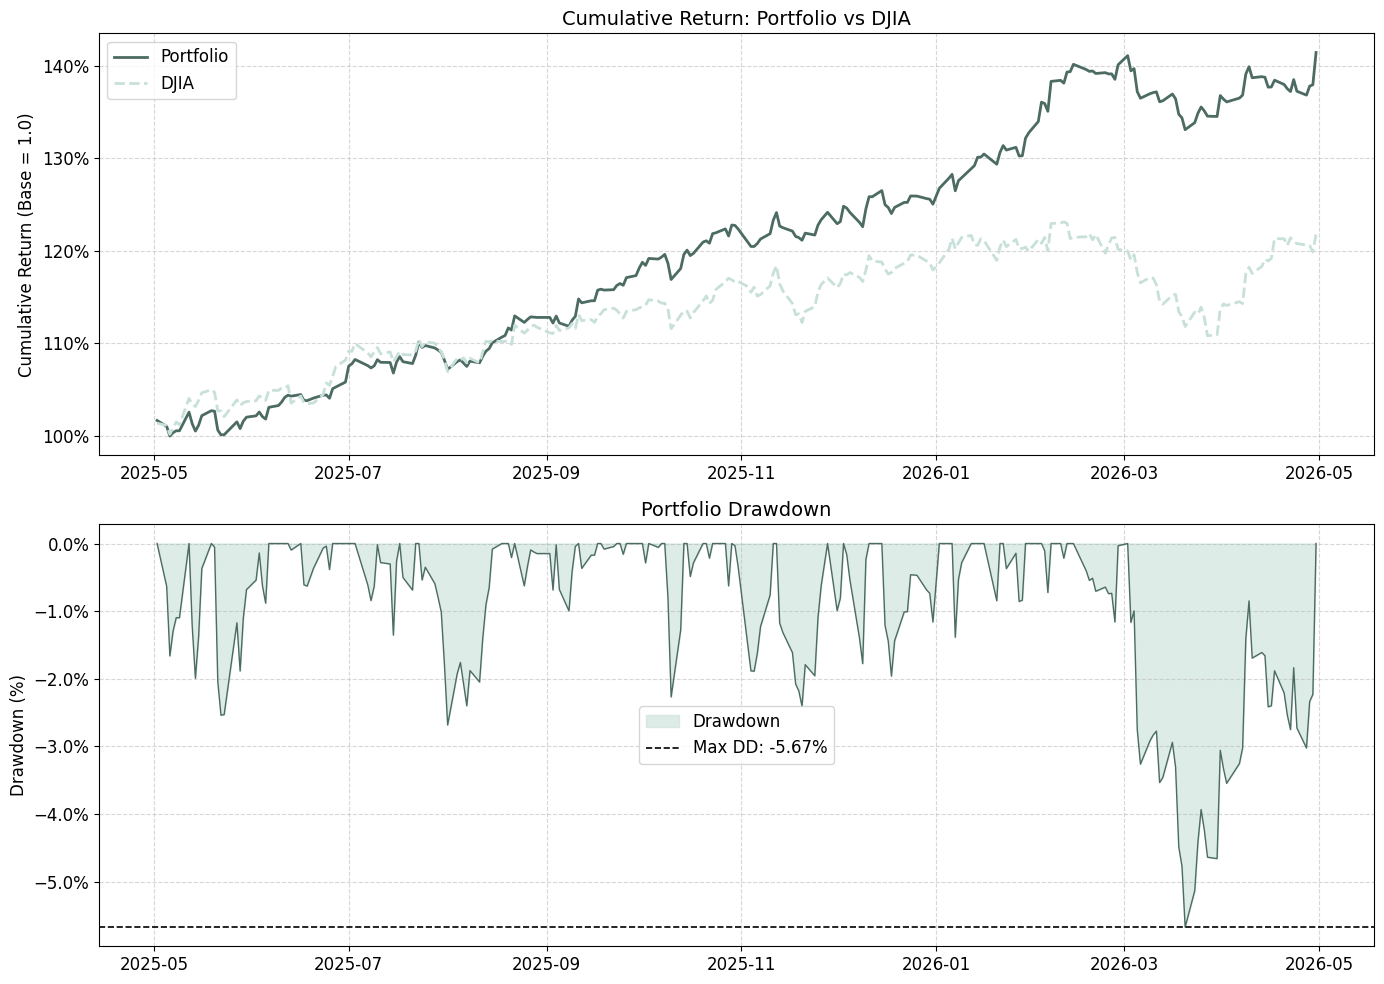

In [ ]:
#DRAWDOWN & CUMULATIVE RETURN CHART
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Panel 1: Cumulative Returns
cum_port  = (1 + port_daily_a).cumprod()
cum_bench = (1 + djia_daily_a).cumprod()

axes[0].plot(cum_port.index,  cum_port.values,  label='Portfolio',  color='#4c6b63', linewidth=2)
axes[0].plot(cum_bench.index, cum_bench.values, label='DJIA',       color='#c8e0da',    linewidth=2, linestyle='--')
axes[0].set_title("Cumulative Return: Portfolio vs DJIA", fontsize=14)
axes[0].set_ylabel("Cumulative Return (Base = 1.0)")
axes[0].legend(fontsize=12)
axes[0].grid(linestyle='--', alpha=0.5)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

# Panel 2: Portfolio Drawdown
axes[1].fill_between(drawdown.index, drawdown.values * 100, 0, color='#c8e0da', alpha=0.6, label='Drawdown')
axes[1].plot(drawdown.index, drawdown.values * 100, color='#4c6b63', linewidth=1)
axes[1].axhline(max_dd * 100, linestyle='--', color='black', linewidth=1.2, label=f'Max DD: {max_dd:.2%}')
axes[1].set_title("Portfolio Drawdown", fontsize=14)
axes[1].set_ylabel("Drawdown (%)")
axes[1].legend(fontsize=12)
axes[1].grid(linestyle='--', alpha=0.5)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()


## **STYLE ANALYSIS**

In [ ]:
#FUND PEFORMANCE DECOMPOSITION
benchmark_component = beta * (ann_ret_bench - risk_free_rate) + risk_free_rate
selection_component = ann_ret_port - benchmark_component

fund_decomp = pd.DataFrame({
    'PERFORMANCE TRACKING': [
        'Fund Return',
        'Benchmark Component',
        'Selection Component',
        'Tracking Error'
    ],
    'RETURN': [
        ann_ret_port,
        benchmark_component,
        selection_component,
        tracking_err
    ],
    'WEIGHT': [
        1.0,
        beta,
        1.0 - beta,
        np.nan
    ]
})

display_fd = fund_decomp.copy()
display_fd['RETURN'] = display_fd['RETURN'].map('{:.2%}'.format)
display_fd['WEIGHT'] = display_fd['WEIGHT'].apply(lambda x: f'{x:.2%}' if not np.isnan(x) else '—')


print("Fund Performance Decomposition")

ipy_display(display_fd)

Fund Performance Decomposition


,PERFORMANCE TRACKING,RETURN,WEIGHT
0,Fund Return,42.06%,100.00%
1,Benchmark Component,15.97%,65.56%
2,Selection Component,26.09%,34.44%
3,Tracking Error,8.63%,—
